<a href="https://colab.research.google.com/github/Janeyy-A/PINN_KAN-PIKAN/blob/main/KAN_Const_Gaus_UnknSources.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KAN — 2D Advection-Diffusion PDE: Source Term Experiments

$$\\frac{\\partial u}{\\partial t} + c_x \\frac{\\partial u}{\\partial x} + c_y \\frac{\\partial u}{\\partial y} = D\\left(\\frac{\\partial^2 u}{\\partial x^2} + \\frac{\\partial^2 u}{\\partial y^2}\\right) + S(x, y, t)$$

**IC:** $u(x,y,0)=\\sin(2\\pi xy/L^2)$ &nbsp;&nbsp; **BC:** $u=0$ (Dirichlet) &nbsp;&nbsp; **Focus:** second spatial dimension ($y$)

## 0. Imports & Shared Setup

In [ ]:
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:  {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device:     {torch.cuda.get_device_name(0)}')

PyTorch version: 2.10.0+cu128
CUDA available:  True
CUDA device:     Tesla T4


In [ ]:
import os, gc, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type != 'cuda':
    raise RuntimeError(
        'GPU not detected! In Kaggle: Settings > Accelerator > GPU T4, '
        'then Session > Restart & Run All.'
    )

if os.path.isdir('/kaggle/working'):
    OUT_DIR  = '/kaggle/working/kan_source_outputs'
    CKPT_DIR = '/kaggle/working/kan_source_checkpoints'
else:
    OUT_DIR  = '/content/kan_source_outputs'
    CKPT_DIR = '/content/kan_source_checkpoints'
os.makedirs(OUT_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
print('Output dir     :', OUT_DIR)
print('Checkpoint dir :', CKPT_DIR)

def ckpt_path(name): return os.path.join(CKPT_DIR, f'{name}.pt')

def save_ckpt(name, payload):
    torch.save(payload, ckpt_path(name))
    print(f'  [ckpt] saved  -> {name}.pt')

def load_ckpt(name):
    p = ckpt_path(name)
    if os.path.exists(p):
        data = torch.load(p, map_location='cpu', weights_only=False)
        print(f'  [ckpt] loaded <- {name}.pt')
        return data
    return None

def save_and_show(filename):
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f'  -> saved {filename}')

Device: cuda
Output dir     : /kaggle/working/kan_source_outputs
Checkpoint dir : /kaggle/working/kan_source_checkpoints


## 1. Shared PDE Parameters

In [ ]:
L      = 2.0
CX     = 1.0
CY     = 1.0
D      = 0.5
T      = 1.0
BC_VAL = 0.0

SOURCE_STRENGTH = 1.0

GAUSS_A     = 1.0
GAUSS_X0    = L / 2
GAUSS_Y0    = L / 2
GAUSS_SIGMA = 0.3

Nx = 80;  Ny = 80
DX = L / Nx;  DY = L / Ny
DT = 2e-3;    Nt = int(T / DT)

x_grid = np.linspace(0.0, L, Nx + 1)
y_grid = np.linspace(0.0, L, Ny + 1)

def ic_xy(x, y):
    return np.sin(2.0 * np.pi / L**2 * x * y)

def normalise_inputs(x, y, t):
    return 2.0*x/L - 1.0, 2.0*y/L - 1.0, 2.0*t/T - 1.0

# Unknown source: superposition of two off-centre Gaussians.
# The specific formula is intentionally defined here but not revealed to the model.
UK_A1, UK_X1, UK_Y1, UK_S1 = 0.8, L*0.3, L*0.7, 0.2
UK_A2, UK_X2, UK_Y2, UK_S2 = 0.6, L*0.7, L*0.3, 0.2

print('=' * 60)
print(f'  Domain  : x,y in [0,{L}]  t in [0,{T}]')
print(f'  Grid    : Nx=Ny={Nx}  Nt={Nt}')
print(f'  cx={CX}  cy={CY}  D={D}')
print(f'  IC : u(x,y,0) = sin(2π/L²·xy)')
print(f'  BC : u = {BC_VAL} (Dirichlet, all boundaries)')
print(f'  Constant source  : S = {SOURCE_STRENGTH}')
print(f'  Gaussian source  : A={GAUSS_A}  x0={GAUSS_X0}  y0={GAUSS_Y0}  σ={GAUSS_SIGMA}')
print(f'  Unknown source   : two off-centre Gaussians (details in Section 16)')
print('=' * 60)

  Domain  : x,y in [0,2.0]  t in [0,1.0]
  Grid    : Nx=Ny=80  Nt=500
  cx=1.0  cy=1.0  D=0.5
  IC : u(x,y,0) = sin(2π/L²·xy)
  BC : u = 0.0 (Dirichlet, all boundaries)
  Constant source  : S = 1.0
  Gaussian source  : A=1.0  x0=1.0  y0=1.0  σ=0.3
  Unknown source   : two off-centre Gaussians (details in Section 16)


## 2. Ground Truth — ADI Crank–Nicolson Solver

In [ ]:
def thomas(a, b, c, d):
    n = len(b)
    cp = np.zeros(n-1);  dp = np.zeros(n)
    cp[0] = c[0]/b[0];   dp[0] = d[0]/b[0]
    for i in range(1, n-1):
        m = b[i] - a[i-1]*cp[i-1]
        cp[i] = c[i]/m;  dp[i] = (d[i] - a[i-1]*dp[i-1])/m
    dp[-1] = (d[-1] - a[-1]*dp[-2]) / (b[-1] - a[-1]*cp[-1])
    sol = np.zeros(n);  sol[-1] = dp[-1]
    for i in reversed(range(n-1)):
        sol[i] = dp[i] - cp[i]*sol[i+1]
    return sol


def solve_adi(source=0.0):
    """source: scalar constant or (Ny+1, Nx+1) spatial array."""
    src     = np.asarray(source, dtype=np.float64)
    src_int = src[1:-1, 1:-1] if src.ndim > 0 else float(src)
    active  = src.ndim > 0 or float(src) != 0.0

    t = np.linspace(0, T, Nt + 1)
    C = np.zeros((Nt+1, Ny+1, Nx+1))
    X, Y = np.meshgrid(x_grid, y_grid, indexing='xy')
    C[0] = ic_xy(X, Y)
    C[0, 0,:] = C[0,-1,:] = C[0,:,0] = C[0,:,-1] = BC_VAL

    rx = D*DT/(2*DX*DX);  ry = D*DT/(2*DY*DY)
    ax_d=-rx*np.ones(Nx-2); bx_d=(1+2*rx)*np.ones(Nx-1); cx_d=-rx*np.ones(Nx-2)
    ay_d=-ry*np.ones(Ny-2); by_d=(1+2*ry)*np.ones(Ny-1); cy_d=-ry*np.ones(Ny-2)

    for n in range(Nt):
        U = C[n].copy()
        A = np.zeros_like(U)
        A[:,1:-1] += CX*(U[:,1:-1]-U[:,:-2])/DX
        A[1:-1,:] += CY*(U[1:-1,:]-U[:-2,:])/DY
        Lap = np.zeros_like(U)
        Lap[1:-1,1:-1] = (
            (U[1:-1,2:]-2*U[1:-1,1:-1]+U[1:-1,:-2])/(DX*DX)
          + (U[2:,1:-1]-2*U[1:-1,1:-1]+U[:-2,1:-1])/(DY*DY))
        RHS = U - DT*A + (D*DT/2)*Lap
        if active:
            RHS[1:-1, 1:-1] += DT * src_int
        Ustar = U.copy()
        for j in range(1, Ny): Ustar[j,1:-1] = thomas(ax_d,bx_d,cx_d,RHS[j,1:-1])
        Ustar[0,:]=Ustar[-1,:]=Ustar[:,0]=Ustar[:,-1]=BC_VAL
        Un = Ustar.copy()
        for i in range(1, Nx): Un[1:-1,i] = thomas(ay_d,by_d,cy_d,Ustar[1:-1,i])
        Un[0,:]=Un[-1,:]=Un[:,0]=Un[:,-1]=BC_VAL
        C[n+1] = Un

    return t, C


print('Solving No-Source GT (S=0) ...', flush=True)
t0 = time.time()
t_sol, C_gt = solve_adi(source=0.0)
print(f'  Done in {time.time()-t0:.2f}s  shape: {C_gt.shape}')

Solving No-Source GT (S=0) ...
  Done in 10.16s  shape: (501, 81, 81)


## 3. KAN Model Definition & Shared Utilities

In [ ]:
class VKANLayer(nn.Module):
    def __init__(self, in_dim, out_dim, grid_size=5, spline_order=3,
                 grid_lo=-1.0, grid_hi=1.0):
        super().__init__()
        self.in_dim  = in_dim
        self.out_dim = out_dim
        self.k       = spline_order
        n_basis      = grid_size + spline_order
        self.coeff   = nn.Parameter(torch.zeros(in_dim, out_dim, n_basis))
        nn.init.normal_(self.coeff, std=0.1)
        self.res_w   = nn.Parameter(torch.zeros(in_dim, out_dim))
        h     = (grid_hi - grid_lo) / grid_size
        knots = torch.linspace(
            grid_lo - spline_order*h, grid_hi + spline_order*h,
            grid_size + 2*spline_order + 1)
        self.register_buffer('knots', knots)

    def _basis(self, x):
        k=self.k; t=self.knots; n=len(t)-k-1
        xv=x.unsqueeze(-1); tv=t.view(1,1,-1)
        B=((xv>=tv[:,:,:-1])&(xv<tv[:,:,1:])).float()
        for r in range(1,k+1):
            tL=tv[:,:,:-(r+1)]; tR=tv[:,:,r:-1]
            dL=(tR-tL).clamp(min=1e-8)
            tL2=tv[:,:,1:-r];   tR2=tv[:,:,r+1:]
            dR=(tR2-tL2).clamp(min=1e-8)
            B=((xv-tL)/dL)*B[:,:,:-1]+((tR2-xv)/dR)*B[:,:,1:]
        return B[:,:,:n]

    def forward(self, x):
        B      = self._basis(x)
        spline = torch.einsum('bin,ion->bio', B, self.coeff)
        res    = torch.einsum('bi,io->bio', F.silu(x), self.res_w)
        return (spline + 0.1*res).sum(dim=1)


class KAN(nn.Module):
    def __init__(self, widths, grid_size=5, spline_order=3):
        super().__init__()
        layers, norms = [], []
        for i in range(len(widths)-1):
            layers.append(VKANLayer(widths[i], widths[i+1], grid_size, spline_order))
            if i < len(widths)-2:
                norms.append(nn.LayerNorm(widths[i+1]))
        self.layers = nn.ModuleList(layers)
        self.norms  = nn.ModuleList(norms)

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.norms): x = self.norms[i](x)
        return x

print('KAN model class defined.')

KAN model class defined.


In [ ]:
KAN_WIDTHS     = [3, 32, 32, 32, 1]
KAN_GRID_SIZE  = 8
KAN_SPLINE_ORD = 3
KAN_MAX_WALL   = 7200.0
KAN_THRESHOLD  = 1e-6
KAN_PATIENCE   = 50
KAN_MAX_EPOCHS = 5000
BATCH          = 512
CHUNK          = 4096


def build_targets(C_gt_array):
    snap_U = C_gt_array[snap_idx_list].transpose(0, 2, 1)
    return np.concatenate([snap_U[k].astype(np.float32).ravel()
                           for k in range(len(snap_t))])


def make_data_loaders(targets):
    X_tr = torch.from_numpy(inputs_kan_n[tr])
    y_tr = torch.from_numpy(targets[tr]).unsqueeze(1)
    X_va = torch.from_numpy(inputs_kan_n[va])
    y_va = torch.from_numpy(targets[va]).unsqueeze(1)
    train_l = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH, shuffle=True)
    val_l   = DataLoader(TensorDataset(X_va, y_va), batch_size=BATCH*8)
    return train_l, val_l, len(X_tr), len(X_va)


def train_kan_model(model, train_loader, val_loader, n_tr, n_va, ckpt_name):
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=15, factor=0.5, min_lr=5e-6)
    criterion = nn.MSELoss()

    _ckpt = load_ckpt(ckpt_name)
    if _ckpt is not None:
        model.load_state_dict(_ckpt['model_state']); model.to(device)
        train_losses=_ckpt['train_losses']; val_losses=_ckpt['val_losses']
        lr_history=_ckpt['lr_history'];     best_val=_ckpt['best_val']
        best_state=_ckpt['best_state'];     no_improve=_ckpt['no_improve']
        stop_reason=_ckpt['stop_reason'];   prev_val=_ckpt['prev_val']
        start_epoch=_ckpt['epoch']+1;       wall_start=time.time()
        print(f'Resumed from epoch {_ckpt["epoch"]}  best_val={best_val:.6f}')
    else:
        train_losses,val_losses,lr_history=[],[],[]
        best_val=float('inf'); best_state=None
        no_improve=0; stop_reason='max_epochs'; prev_val=float('inf')
        start_epoch=1; wall_start=time.time()

    print(f'\n{"Epoch":>6} | {"Train Loss":>12} | {"Val MSE":>12} | {"LR":>9} | {"Wall":>7}')
    print('-'*60)

    for epoch in range(start_epoch, KAN_MAX_EPOCHS+1):
        elapsed = time.time()-wall_start
        if elapsed >= KAN_MAX_WALL: stop_reason='time_limit'; break

        model.train(); t_loss=0.0
        for xb,yb in train_loader:
            xb,yb=xb.to(device),yb.to(device)
            optimizer.zero_grad()
            loss=criterion(model(xb),yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),1.0)
            optimizer.step(); t_loss+=loss.item()*xb.size(0)
        t_loss/=n_tr

        model.eval(); v_loss=0.0
        with torch.no_grad():
            for xb,yb in val_loader:
                xb,yb=xb.to(device),yb.to(device)
                v_loss+=criterion(model(xb),yb).item()*xb.size(0)
        v_loss/=n_va

        scheduler.step(v_loss); cur_lr=optimizer.param_groups[0]['lr']
        train_losses.append(t_loss); val_losses.append(v_loss); lr_history.append(cur_lr)

        if v_loss < best_val:
            best_val=v_loss
            best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}

        delta=abs(prev_val-v_loss)
        if epoch%50==0 or epoch==1:
            print(f'{epoch:>6} | {t_loss:>12.6f} | {v_loss:>12.6f} | {cur_lr:>9.2e} | {elapsed:>5.1f}s')

        if epoch%50==0:
            save_ckpt(ckpt_name,{
                'epoch':epoch,'model_state':{k:v.cpu().clone() for k,v in model.state_dict().items()},
                'train_losses':train_losses,'val_losses':val_losses,'lr_history':lr_history,
                'best_val':best_val,'best_state':best_state,'no_improve':no_improve,
                'stop_reason':stop_reason,'prev_val':v_loss})

        if epoch>50:
            no_improve=no_improve+1 if delta<KAN_THRESHOLD else 0
            if no_improve>=KAN_PATIENCE:
                stop_reason='convergence'
                print(f'\n  Converged at epoch {epoch}! |ΔLoss|={delta:.2e} < {KAN_THRESHOLD:.0e}')
                break
        prev_val=v_loss

    if best_state: model.load_state_dict(best_state); model.to(device)
    total_time=time.time()-wall_start; final_epoch=len(train_losses)

    print('\n'+'='*60)
    print(f'  Stop reason   : {stop_reason}')
    print(f'  Epochs run    : {final_epoch}')
    print(f'  Best val MSE  : {best_val:.6f}')
    print(f'  Training time : {total_time:.1f}s ({total_time/60:.1f} min)')
    print('='*60)

    result = dict(train_losses=train_losses, val_losses=val_losses, lr_history=lr_history,
                  best_val=best_val, best_state=best_state, stop_reason=stop_reason,
                  final_epoch=final_epoch, total_time=total_time)
    save_ckpt(ckpt_name+'_done', {**result, 'model_state': best_state})
    return result


def evaluate_kan_model(model, targets):
    model.eval()
    X_all = torch.from_numpy(inputs_kan_n).to(device)
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_all), CHUNK):
            preds.append(model(X_all[i:i+CHUNK]).cpu().numpy().ravel())
    pred_all = np.concatenate(preds)

    mse_full = float(np.mean((pred_all-targets)**2))
    rmse_all = float(np.sqrt(mse_full))
    rel_err  = float(np.mean(np.abs(pred_all-targets))/(np.mean(np.abs(targets))+1e-12))

    print(f'  Full MSE      : {mse_full:.6f}')
    print(f'  RMSE          : {rmse_all:.6f}')
    print(f'  Rel. L1 error : {rel_err*100:.2f}%')

    pred_snaps = pred_all.reshape(len(snap_t), Nx+1, Ny+1)
    true_snaps = targets.reshape(len(snap_t), Nx+1, Ny+1)
    rmse_t = [float(np.sqrt(np.mean((pred_snaps[k]-true_snaps[k])**2)))
              for k in range(len(snap_t))]

    return dict(pred_snaps=pred_snaps, true_snaps=true_snaps,
                mse_full=mse_full, rmse_all=rmse_all, rel_err=rel_err, rmse_t=rmse_t)


def plot_training_metrics(result, suptitle, fname):
    ep = np.arange(1, result['final_epoch']+1)
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    fig.suptitle(suptitle, fontsize=13, fontweight='bold')
    ax=axes[0]
    ax.semilogy(ep,result['train_losses'],lw=1.5,color='#2563EB',label='Train Loss')
    ax.semilogy(ep,result['val_losses'],  lw=1.5,color='#DC2626',ls='--',label='Val Loss')
    ax.axhline(KAN_THRESHOLD,color='gray',ls=':',lw=1.2,label=f'Threshold {KAN_THRESHOLD:.0e}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log)'); ax.set_title('Train & Val Loss')
    ax.legend(fontsize=10); ax.grid(True,alpha=0.3)
    ax=axes[1]
    ax.semilogy(ep,result['lr_history'],lw=1.5,color='#059669')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate'); ax.set_title('LR Schedule')
    ax.grid(True,alpha=0.3)
    plt.tight_layout(); save_and_show(fname)


def plot_snapshot_comparison(eval_r, suptitle, fname):
    pred_snaps=eval_r['pred_snaps']; true_snaps=eval_r['true_snaps']
    fig,axes=plt.subplots(3,4,figsize=(20,13))
    fig.suptitle(suptitle, fontsize=13, fontweight='bold')
    for col,si in enumerate(snap_idxs_4):
        tk=snap_t[si]; Ugt=true_snaps[si]; Upd=pred_snaps[si]; err=Upd-Ugt
        vmin=min(Ugt.min(),Upd.min()); vmax=max(Ugt.max(),Upd.max())
        emax=max(abs(err.min()),abs(err.max()))+1e-12
        norm_e=TwoSlopeNorm(vmin=-emax,vcenter=0,vmax=emax)
        ax=axes[0,col]; im=ax.pcolormesh(x_grid,y_grid,Ugt.T,cmap='viridis',vmin=vmin,vmax=vmax)
        ax.set_title(f'Ground Truth  t={tk:.3f}',fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)'); plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
        ax=axes[1,col]; im=ax.pcolormesh(x_grid,y_grid,Upd.T,cmap='viridis',vmin=vmin,vmax=vmax)
        ax.set_title(f'KAN Prediction  t={tk:.3f}',fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)'); plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
        ax=axes[2,col]; im=ax.pcolormesh(x_grid,y_grid,err.T,cmap='RdBu_r',norm=norm_e)
        ax.set_title(f'Error  t={tk:.3f}  RMSE={np.sqrt(np.mean(err**2)):.4f}',fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)'); plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
    plt.tight_layout(); save_and_show(fname)


def plot_y_profiles(eval_r, suptitle, fname, color='#2563EB', label='KAN'):
    pred_snaps=eval_r['pred_snaps']; true_snaps=eval_r['true_snaps']
    fig,axes=plt.subplots(2,2,figsize=(14,10))
    fig.suptitle(suptitle, fontsize=13, fontweight='bold')
    for ax,si in zip(axes.ravel(),snap_idxs_4):
        tk=snap_t[si]; gt_y=true_snaps[si,ix_mid,:]; pd_y=pred_snaps[si,ix_mid,:]
        ax.plot(y_grid,gt_y,'k-', lw=2.2,label='Ground Truth')
        ax.plot(y_grid,pd_y,color=color,ls='--',lw=2.2,label=label)
        ax.fill_between(y_grid,gt_y,pd_y,alpha=0.15,color=color,label='|Error|')
        ax.set_title(f't = {tk:.3f}',fontsize=12)
        ax.set_xlabel('y  (second dimension)'); ax.set_ylabel(f'u({x_grid[ix_mid]:.2f}, y, t)')
        ax.legend(fontsize=10); ax.grid(True,alpha=0.3)
    plt.tight_layout(); save_and_show(fname)


def plot_rmse_over_time(eval_r, color, marker, suptitle, fname):
    fig,ax=plt.subplots(figsize=(10,5))
    ax.plot(snap_t,eval_r['rmse_t'],marker+'-',color=color,lw=2,ms=5)
    ax.set_xlabel('Simulation Time t'); ax.set_ylabel('RMSE')
    ax.set_title(suptitle); ax.grid(True,alpha=0.3)
    plt.tight_layout(); save_and_show(fname)


print('Shared utilities defined.')

Shared utilities defined.


## 4. Shared Dataset Preparation

In [ ]:
N_SNAPS       = 100
save_every    = max(1, Nt // N_SNAPS)
snap_idx_list = list(range(0, Nt+1, save_every))
if snap_idx_list[-1] != Nt: snap_idx_list.append(Nt)
snap_t = t_sol[snap_idx_list]

XX, YY = np.meshgrid(x_grid, y_grid, indexing='ij')
inp_list = []
for tk in snap_t:
    t_plane = np.full((Nx+1, Ny+1), tk, dtype=np.float32)
    inp_list.append(np.stack([XX, YY, t_plane], axis=-1).astype(np.float32).reshape(-1, 3))
inputs_kan   = np.concatenate(inp_list, axis=0)
xn,yn,tn     = normalise_inputs(inputs_kan[:,0], inputs_kan[:,1], inputs_kan[:,2])
inputs_kan_n = np.stack([xn,yn,tn], axis=1).astype(np.float32)

rng   = np.random.default_rng(42)
idx   = rng.permutation(len(inputs_kan_n))
split = int(0.85*len(inputs_kan_n))
tr, va = idx[:split], idx[split:]

FS          = 12
snap_idxs_4 = np.linspace(0, len(snap_t)-1, 4, dtype=int)
ix_mid      = (Nx+1)//2

print(f'Dataset inputs : {len(inputs_kan_n):,} samples  (train {len(tr):,} / val {len(va):,})')
print(f'Snapshots      : {len(snap_t)}  (every {save_every} steps)')

Dataset inputs : 662,661 samples  (train 563,261 / val 99,400)
Snapshots      : 101  (every 5 steps)


## 5. KAN — Training  (No Source, S = 0)

In [ ]:
targets_kan = build_targets(C_gt)
train_loader_kan, val_loader_kan, n_tr_kan, n_va_kan = make_data_loaders(targets_kan)

kan_model    = KAN(KAN_WIDTHS, KAN_GRID_SIZE, KAN_SPLINE_ORD).to(device)
kan_n_params = sum(p.numel() for p in kan_model.parameters())
print(f'KAN : {KAN_WIDTHS}  grid={KAN_GRID_SIZE}  order={KAN_SPLINE_ORD}  params={kan_n_params:,}')

kan_result = train_kan_model(
    kan_model, train_loader_kan, val_loader_kan, n_tr_kan, n_va_kan, 'kan')

KAN : [3, 32, 32, 32, 1]  grid=8  order=3  params=26,304

 Epoch |   Train Loss |      Val MSE |        LR |    Wall
------------------------------------------------------------
     1 |     0.007481 |     0.000517 |  3.00e-03 |   0.0s
    50 |     0.000002 |     0.000004 |  1.50e-03 | 733.1s
  [ckpt] saved  -> kan.pt
   100 |     0.000001 |     0.000001 |  7.50e-04 | 1477.2s
  [ckpt] saved  -> kan.pt
   150 |     0.000000 |     0.000000 |  1.88e-04 | 2169.5s
  [ckpt] saved  -> kan.pt

  Converged at epoch 159! |ΔLoss|=5.54e-09 < 1e-06

  Stop reason   : convergence
  Epochs run    : 159
  Best val MSE  : 0.000000
  Training time : 2303.9s (38.4 min)
  [ckpt] saved  -> kan_done.pt


## 6. KAN — Predictions & Metrics

In [ ]:
print('KAN (No Source) — Accuracy vs Ground Truth:')
kan_eval = evaluate_kan_model(kan_model, targets_kan)

KAN (No Source) — Accuracy vs Ground Truth:
  Full MSE      : 0.000000
  RMSE          : 0.000135
  Rel. L1 error : 0.06%


## 7. KAN — Plots

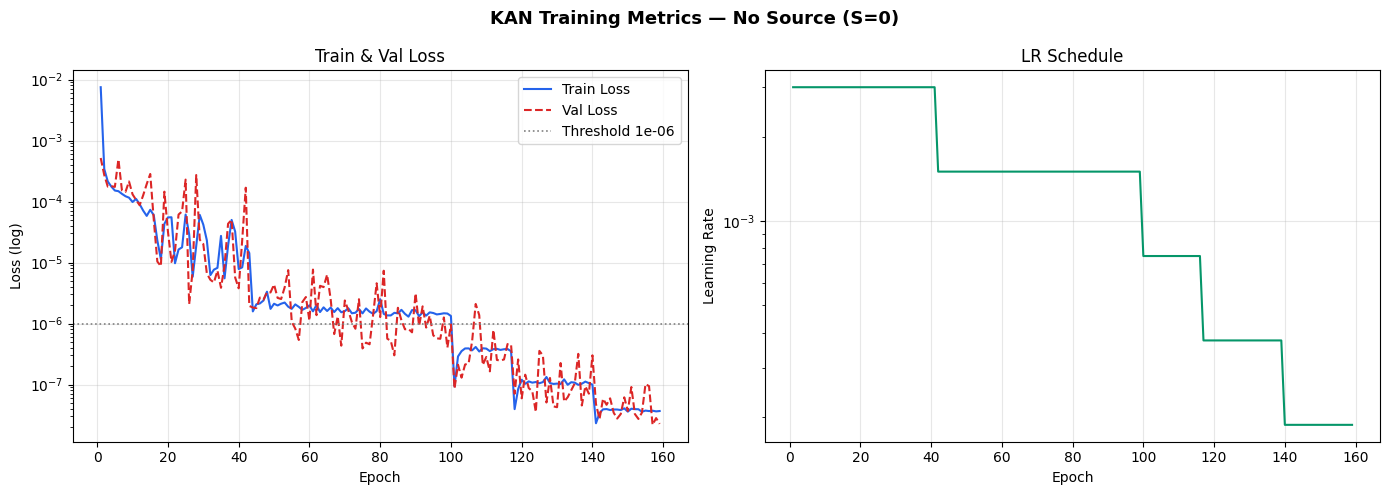

  -> saved KAN_01_training_metrics.png


In [ ]:
plot_training_metrics(
    kan_result,
    'KAN Training Metrics — No Source (S=0)',
    'KAN_01_training_metrics.png')

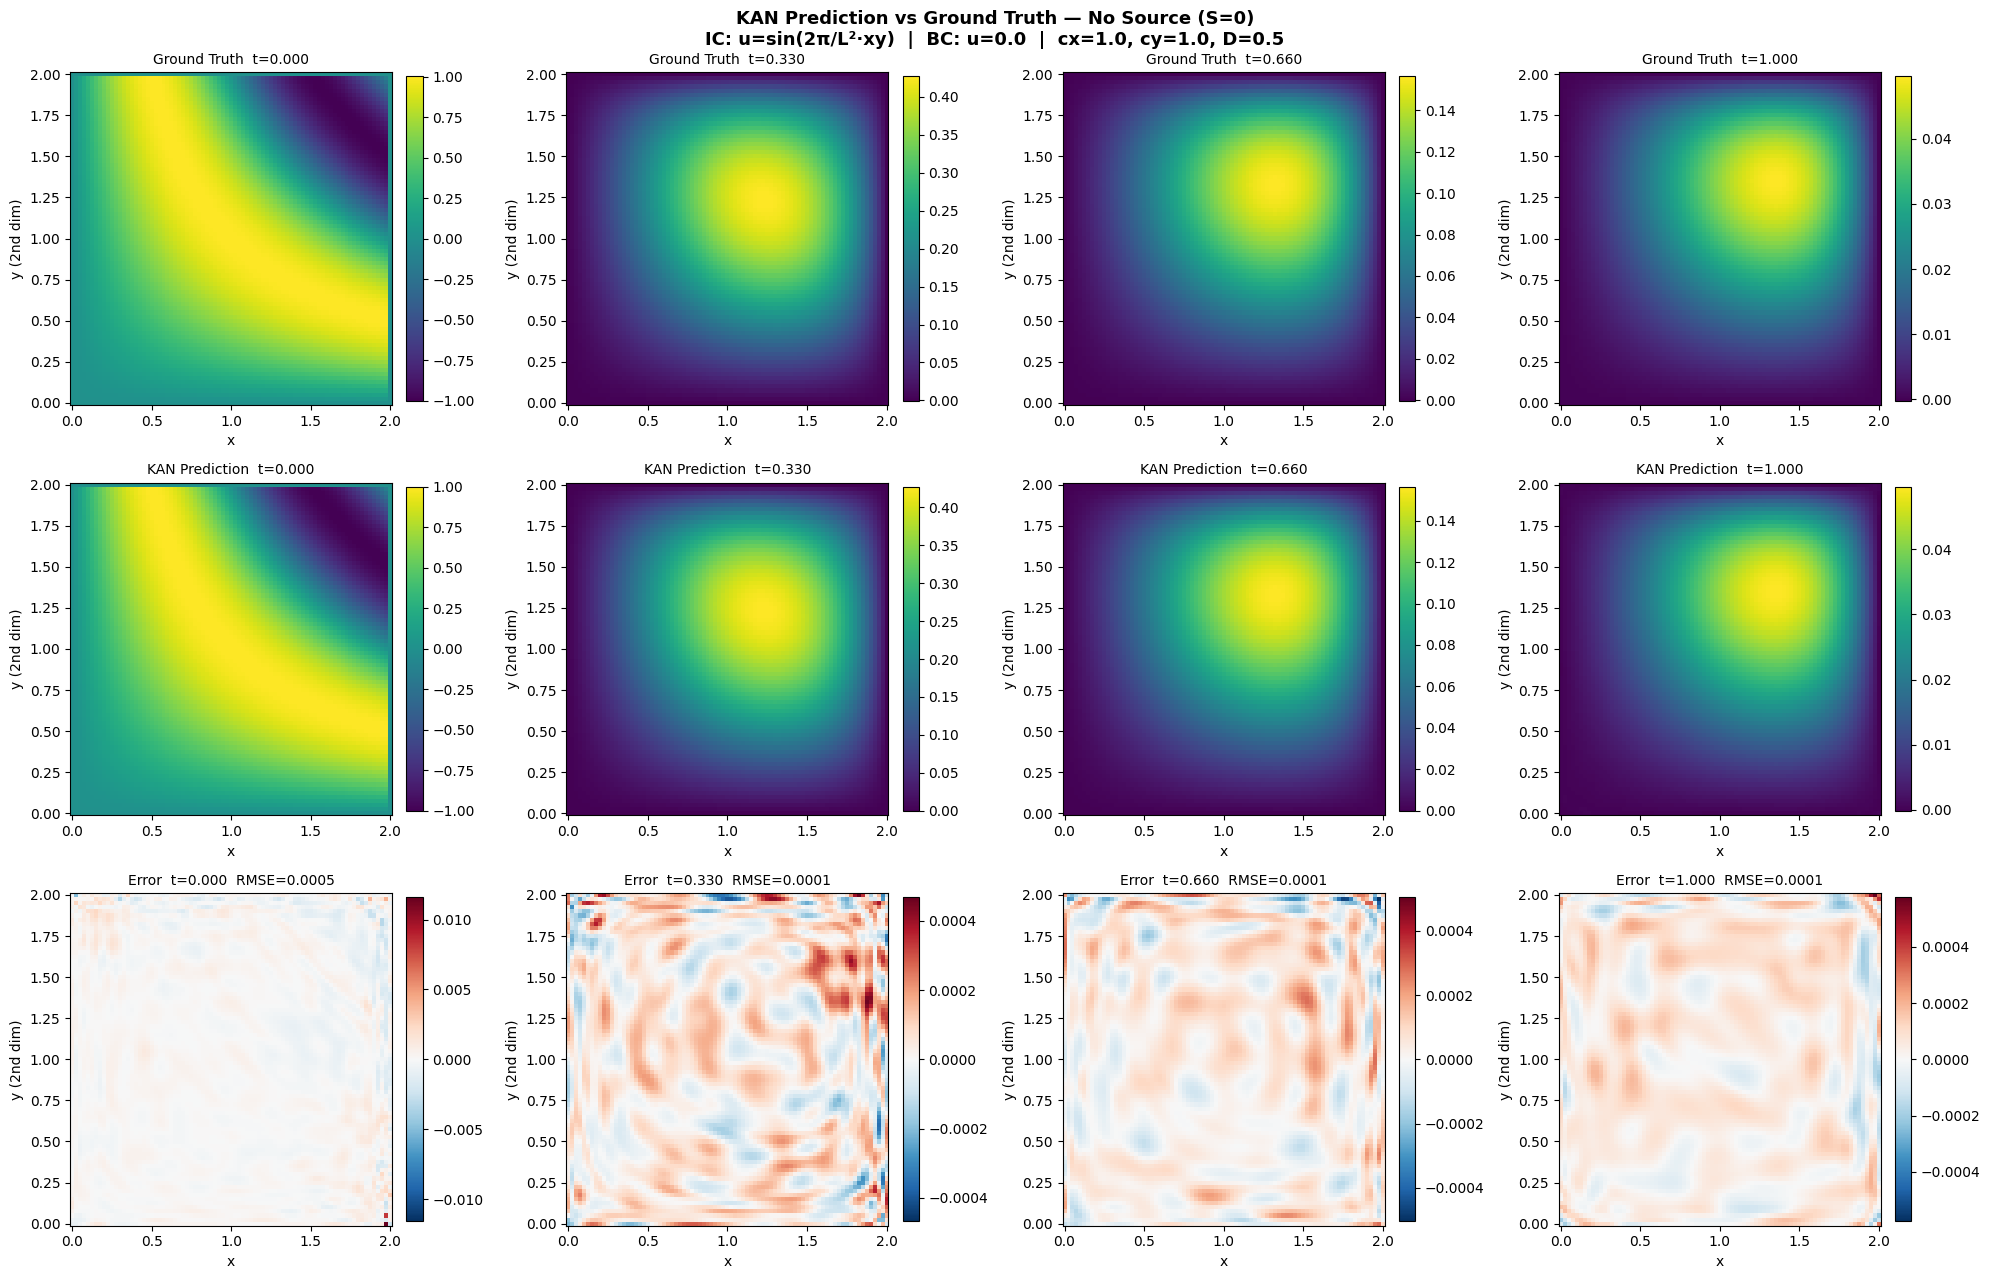

  -> saved KAN_02_snapshot_comparison.png


In [ ]:
plot_snapshot_comparison(
    kan_eval,
    f'KAN Prediction vs Ground Truth — No Source (S=0)\n'
    f'IC: u=sin(2π/L²·xy)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}',
    'KAN_02_snapshot_comparison.png')

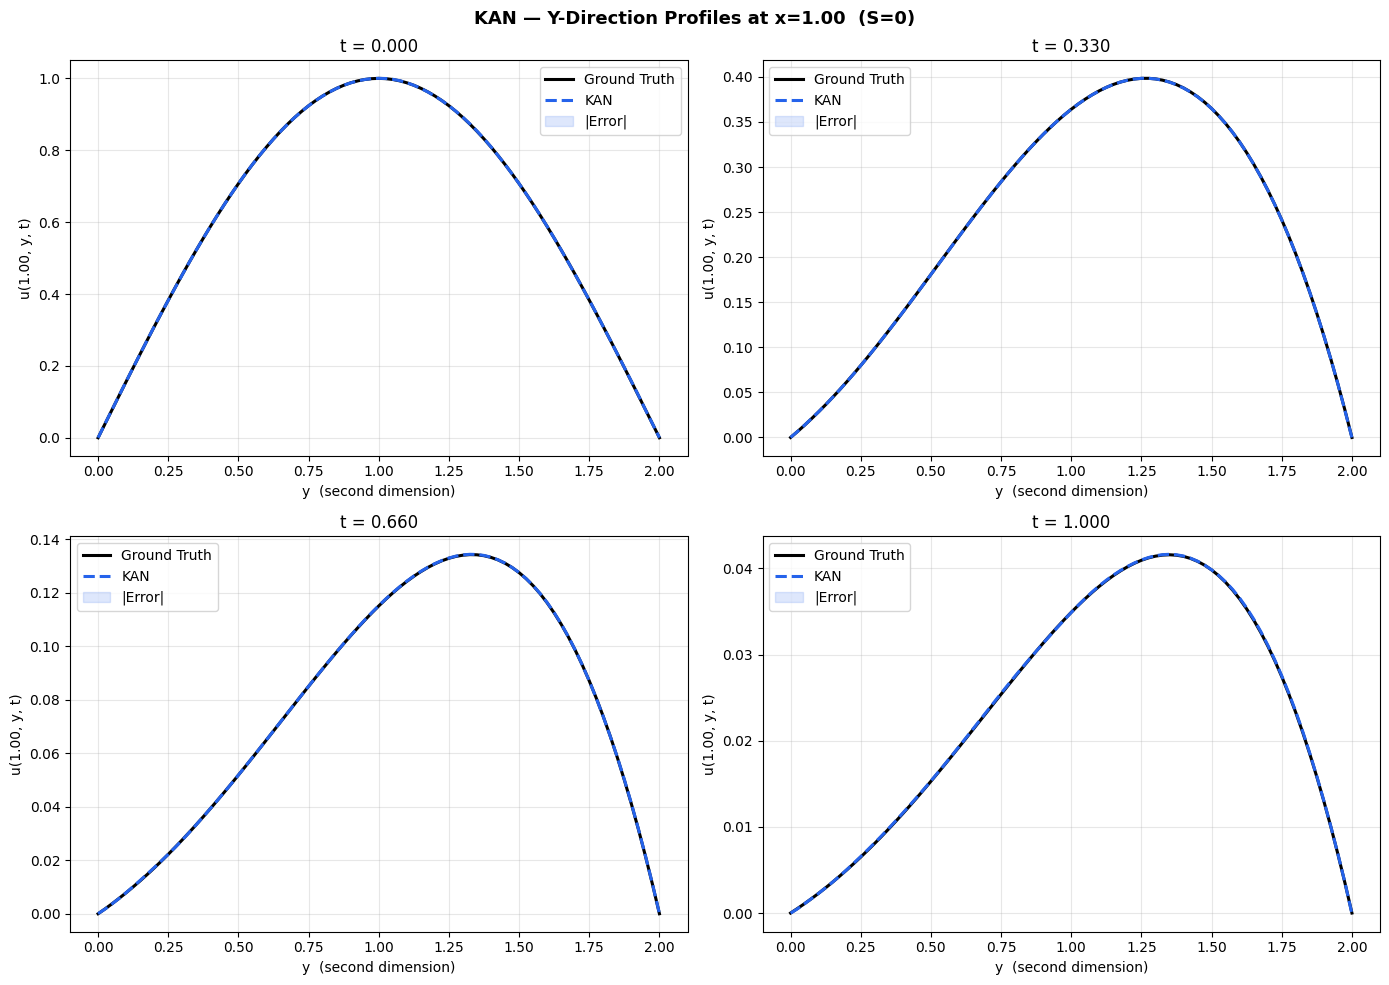

  -> saved KAN_03_y_profiles.png


In [ ]:
plot_y_profiles(
    kan_eval,
    f'KAN — Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  (S=0)',
    'KAN_03_y_profiles.png',
    color='#2563EB', label='KAN')

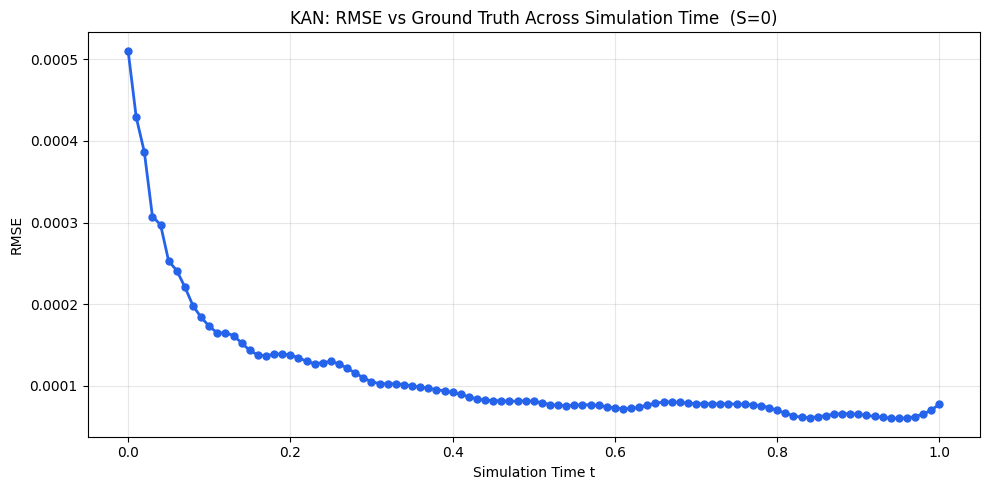

  -> saved KAN_04_rmse_over_time.png


In [ ]:
plot_rmse_over_time(
    kan_eval, '#2563EB', 'o',
    'KAN: RMSE vs Ground Truth Across Simulation Time  (S=0)',
    'KAN_04_rmse_over_time.png')

kan_model.cpu()
torch.cuda.empty_cache()

## 8. KAN + Constant Source — Model Definition

In [ ]:
print(f'Solving Constant-Source GT (S={SOURCE_STRENGTH}) ...', flush=True)
t0 = time.time()
_, C_gt_cs = solve_adi(source=SOURCE_STRENGTH)
print(f'  Done in {time.time()-t0:.2f}s')
print(f'  u range at t=T: [{C_gt_cs[-1].min():.4f}, {C_gt_cs[-1].max():.4f}]')

kan_cs_model    = KAN(KAN_WIDTHS, KAN_GRID_SIZE, KAN_SPLINE_ORD).to(device)
kan_cs_n_params = sum(p.numel() for p in kan_cs_model.parameters())
print(f'KAN-CS : {KAN_WIDTHS}  grid={KAN_GRID_SIZE}  order={KAN_SPLINE_ORD}  params={kan_cs_n_params:,}')

Solving Constant-Source GT (S=1.0) ...
  Done in 9.65s
  u range at t=T: [0.0000, 0.5375]
KAN-CS : [3, 32, 32, 32, 1]  grid=8  order=3  params=26,304


## 9. Constant Training

In [ ]:
targets_kan_cs = build_targets(C_gt_cs)
train_loader_cs, val_loader_cs, n_tr_cs, n_va_cs = make_data_loaders(targets_kan_cs)

kan_cs_result = train_kan_model(
    kan_cs_model, train_loader_cs, val_loader_cs, n_tr_cs, n_va_cs, 'kan_cs')


 Epoch |   Train Loss |      Val MSE |        LR |    Wall
------------------------------------------------------------
     1 |     0.011055 |     0.000730 |  3.00e-03 |   0.0s
    50 |     0.000003 |     0.000001 |  1.50e-03 | 664.1s
  [ckpt] saved  -> kan_cs.pt
   100 |     0.000000 |     0.000000 |  7.50e-04 | 1354.6s
  [ckpt] saved  -> kan_cs.pt

  Converged at epoch 147! |ΔLoss|=1.39e-07 < 1e-06

  Stop reason   : convergence
  Epochs run    : 147
  Best val MSE  : 0.000000
  Training time : 2019.2s (33.7 min)
  [ckpt] saved  -> kan_cs_done.pt


## 10. Constant Predictions & Metrics

In [ ]:
print(f'KAN + Constant Source (S={SOURCE_STRENGTH}) — Accuracy vs Ground Truth:')
kan_cs_eval = evaluate_kan_model(kan_cs_model, targets_kan_cs)

KAN + Constant Source (S=1.0) — Accuracy vs Ground Truth:
  Full MSE      : 0.000000
  RMSE          : 0.000181
  Rel. L1 error : 0.04%


## 11. Constant Plots

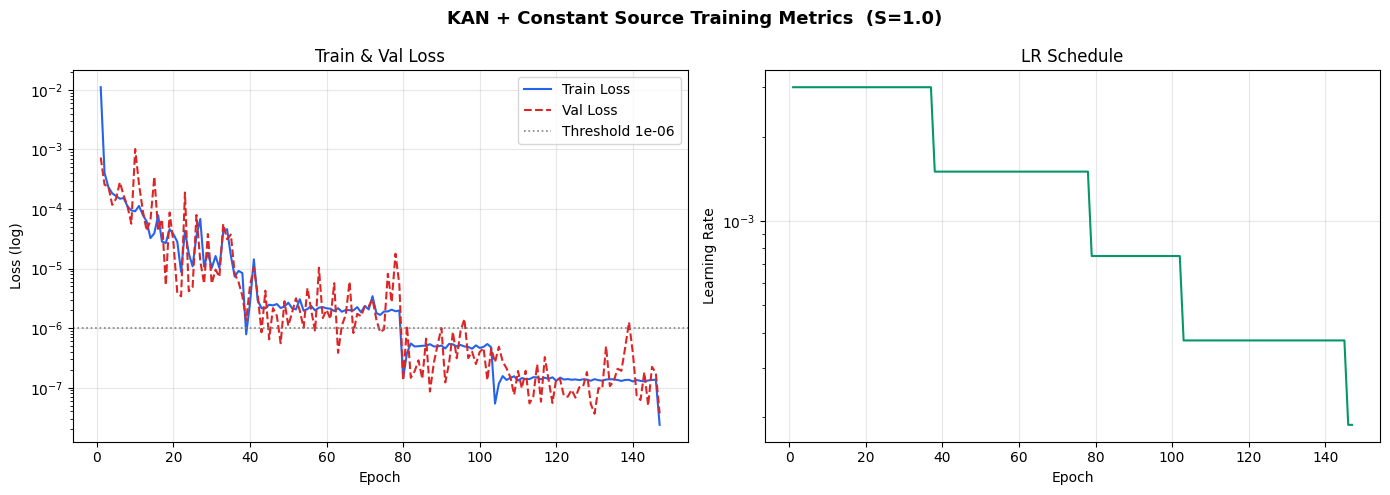

  -> saved KANCS_01_training_metrics.png


In [ ]:
plot_training_metrics(
    kan_cs_result,
    f'KAN + Constant Source Training Metrics  (S={SOURCE_STRENGTH})',
    'KANCS_01_training_metrics.png')

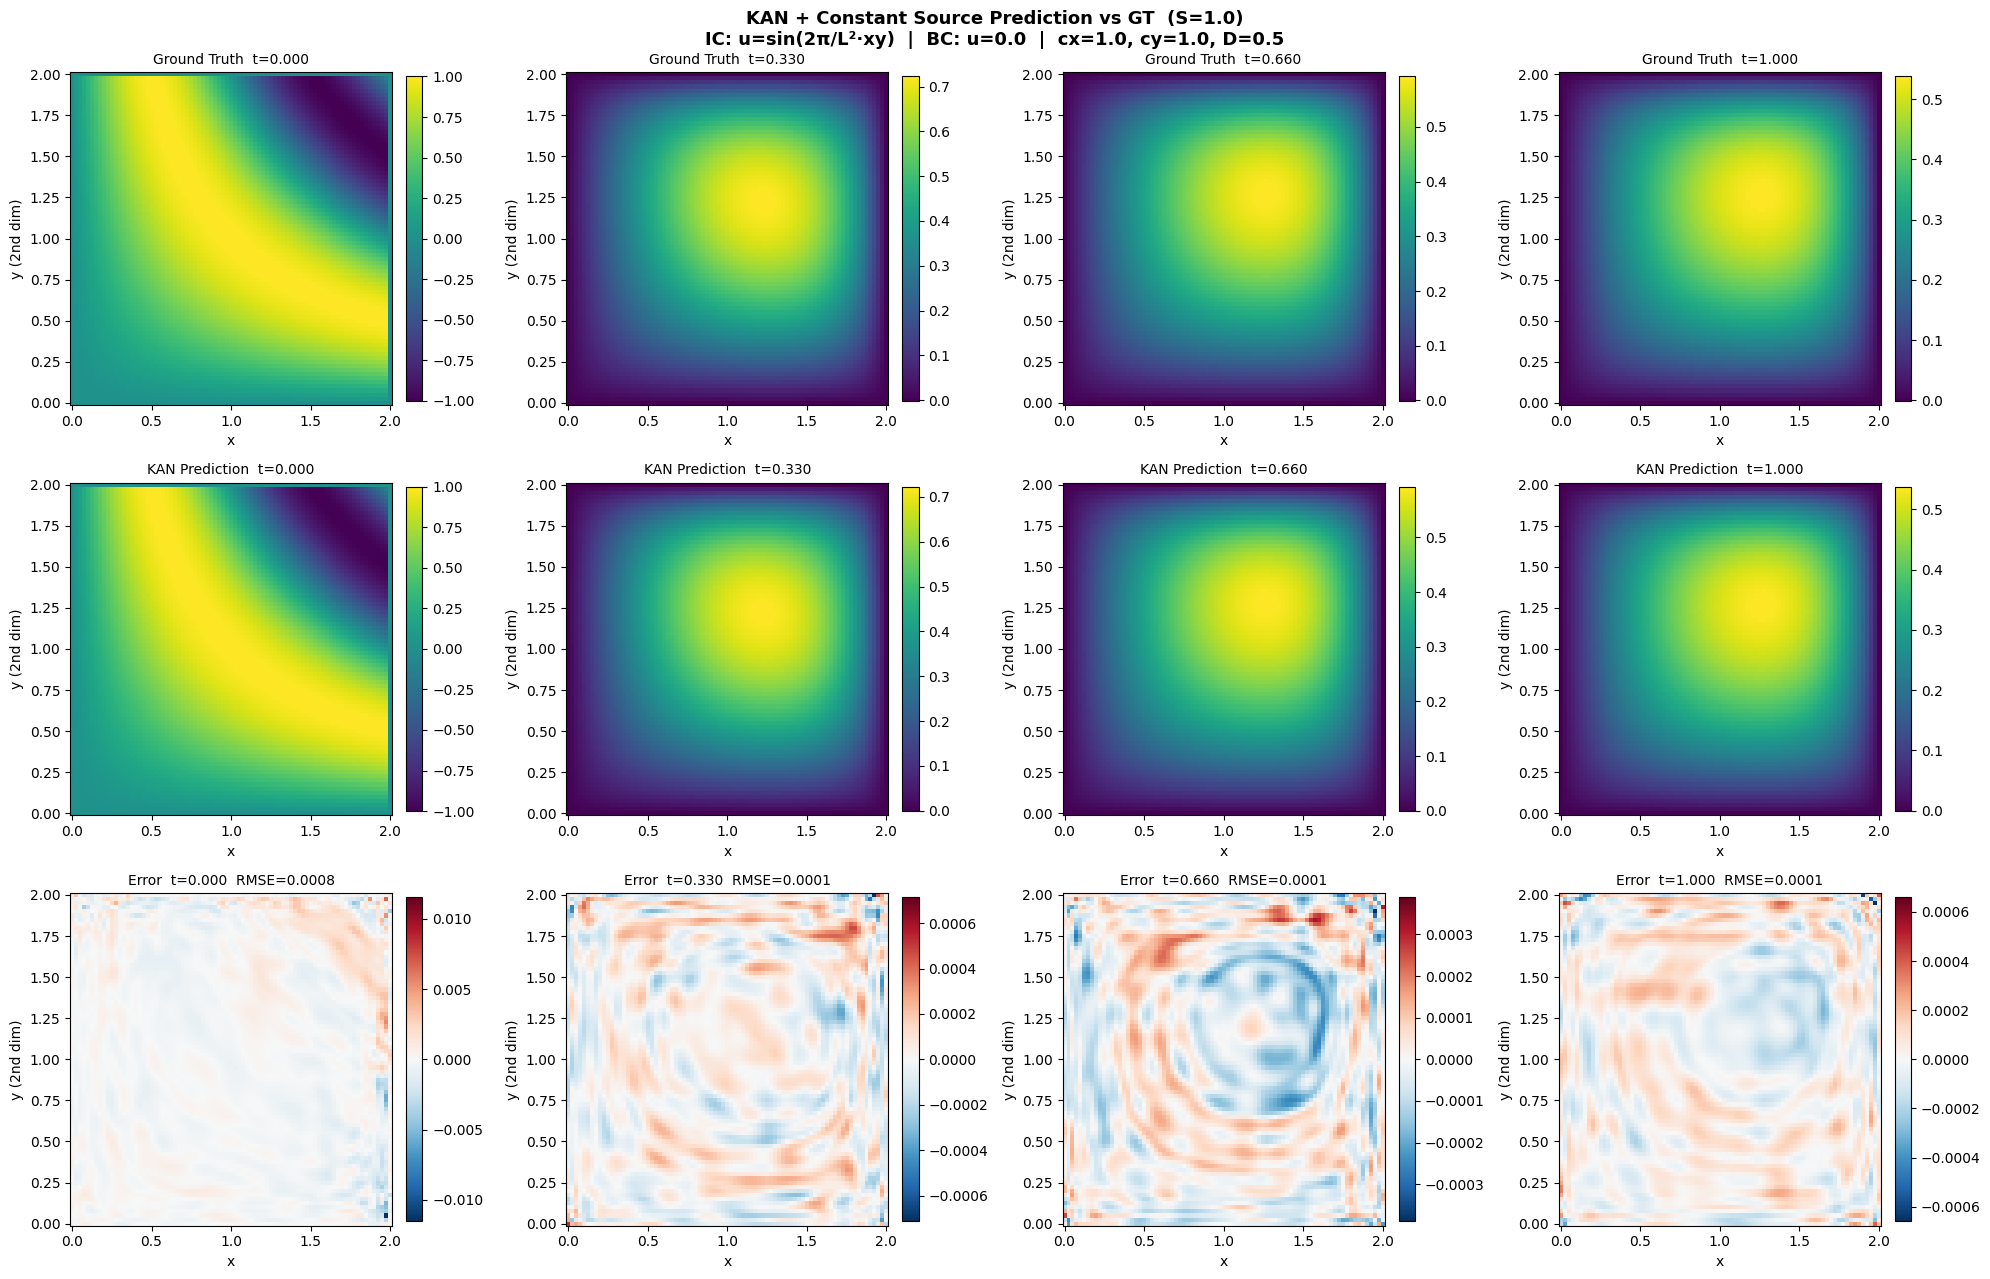

  -> saved KANCS_02_snapshot_comparison.png


In [ ]:
plot_snapshot_comparison(
    kan_cs_eval,
    f'KAN + Constant Source Prediction vs GT  (S={SOURCE_STRENGTH})\n'
    f'IC: u=sin(2π/L²·xy)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}',
    'KANCS_02_snapshot_comparison.png')

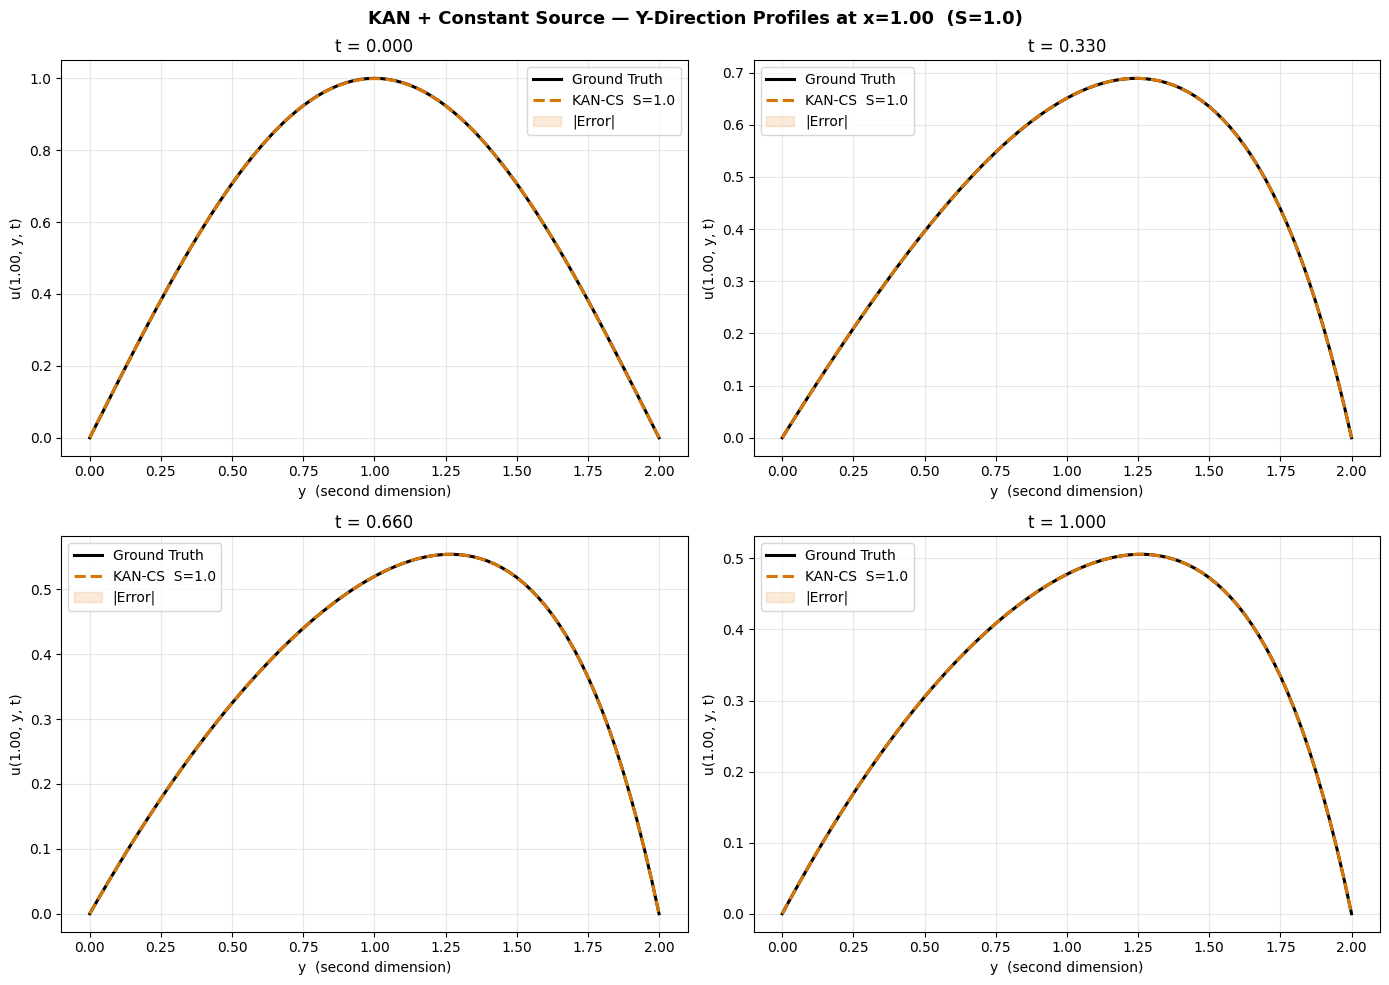

  -> saved KANCS_03_y_profiles.png


In [ ]:
plot_y_profiles(
    kan_cs_eval,
    f'KAN + Constant Source — Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  (S={SOURCE_STRENGTH})',
    'KANCS_03_y_profiles.png',
    color='#D97706', label=f'KAN-CS  S={SOURCE_STRENGTH}')

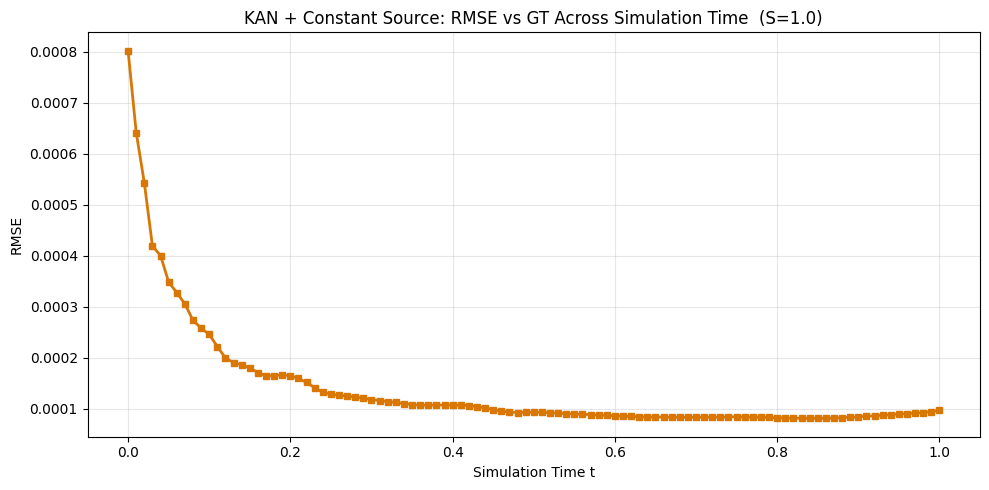

  -> saved KANCS_04_rmse_over_time.png


In [ ]:
plot_rmse_over_time(
    kan_cs_eval, '#D97706', 's',
    f'KAN + Constant Source: RMSE vs GT Across Simulation Time  (S={SOURCE_STRENGTH})',
    'KANCS_04_rmse_over_time.png')

kan_cs_model.cpu()
torch.cuda.empty_cache()

## 12. KAN + Gaussian Source — Model Definition

In [ ]:
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid, indexing='xy')
S_gauss = GAUSS_A * np.exp(
    -((X_mesh - GAUSS_X0)**2 + (Y_mesh - GAUSS_Y0)**2) / (2 * GAUSS_SIGMA**2))

print(f'Solving Gaussian-Source GT (A={GAUSS_A}, x0={GAUSS_X0}, y0={GAUSS_Y0}, σ={GAUSS_SIGMA}) ...', flush=True)
t0 = time.time()
_, C_gt_gs = solve_adi(source=S_gauss)
print(f'  Done in {time.time()-t0:.2f}s')
print(f'  u range at t=T: [{C_gt_gs[-1].min():.4f}, {C_gt_gs[-1].max():.4f}]')

kan_gs_model    = KAN(KAN_WIDTHS, KAN_GRID_SIZE, KAN_SPLINE_ORD).to(device)
kan_gs_n_params = sum(p.numel() for p in kan_gs_model.parameters())
print(f'KAN-GS : {KAN_WIDTHS}  grid={KAN_GRID_SIZE}  order={KAN_SPLINE_ORD}  params={kan_gs_n_params:,}')

Solving Gaussian-Source GT (A=1.0, x0=1.0, y0=1.0, σ=0.3) ...
  Done in 9.86s
  u range at t=T: [0.0000, 0.2213]
KAN-GS : [3, 32, 32, 32, 1]  grid=8  order=3  params=26,304


## 13. Gaussian Training

In [ ]:
targets_kan_gs = build_targets(C_gt_gs)
train_loader_gs, val_loader_gs, n_tr_gs, n_va_gs = make_data_loaders(targets_kan_gs)

kan_gs_result = train_kan_model(
    kan_gs_model, train_loader_gs, val_loader_gs, n_tr_gs, n_va_gs, 'kan_gs')


 Epoch |   Train Loss |      Val MSE |        LR |    Wall
------------------------------------------------------------
     1 |     0.008609 |     0.000534 |  3.00e-03 |   0.0s
    50 |     0.000007 |     0.000027 |  3.00e-03 | 679.1s
  [ckpt] saved  -> kan_gs.pt
   100 |     0.000001 |     0.000001 |  1.50e-03 | 1382.2s
  [ckpt] saved  -> kan_gs.pt
   150 |     0.000000 |     0.000000 |  1.88e-04 | 2124.1s
  [ckpt] saved  -> kan_gs.pt

  Converged at epoch 161! |ΔLoss|=1.41e-08 < 1e-06

  Stop reason   : convergence
  Epochs run    : 161
  Best val MSE  : 0.000000
  Training time : 2301.3s (38.4 min)
  [ckpt] saved  -> kan_gs_done.pt


## 14. Gaussian Predictions & Metrics

In [ ]:
print(f'KAN + Gaussian Source — Accuracy vs Ground Truth:')
kan_gs_eval = evaluate_kan_model(kan_gs_model, targets_kan_gs)

KAN + Gaussian Source — Accuracy vs Ground Truth:
  Full MSE      : 0.000000
  RMSE          : 0.000173
  Rel. L1 error : 0.06%


## 15. Gaussian Plots

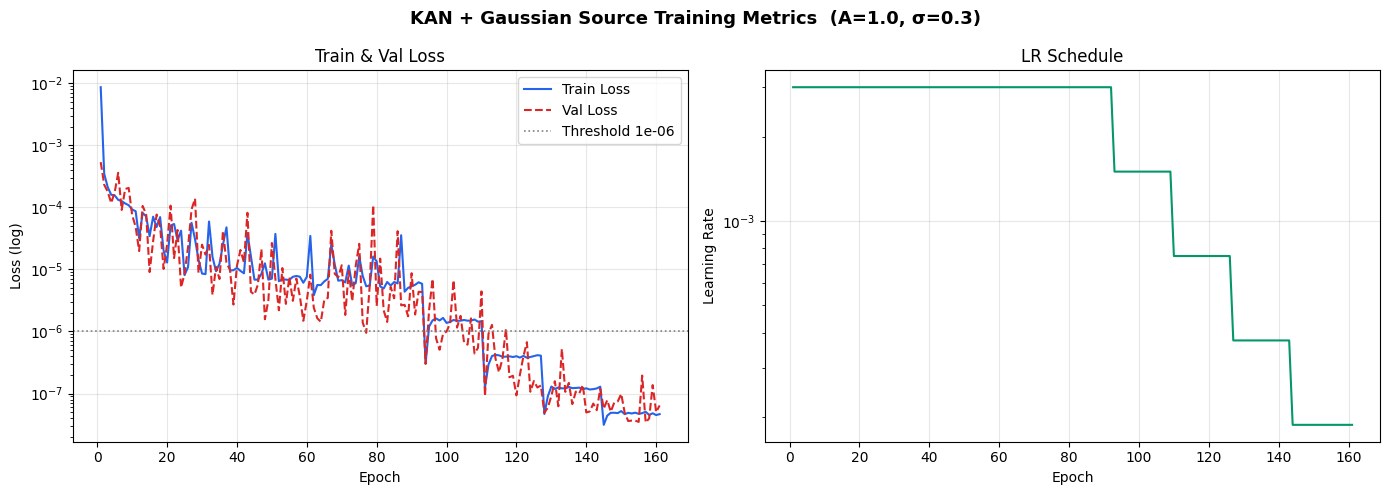

  -> saved KANGS_01_training_metrics.png


In [ ]:
plot_training_metrics(
    kan_gs_result,
    f'KAN + Gaussian Source Training Metrics  (A={GAUSS_A}, σ={GAUSS_SIGMA})',
    'KANGS_01_training_metrics.png')

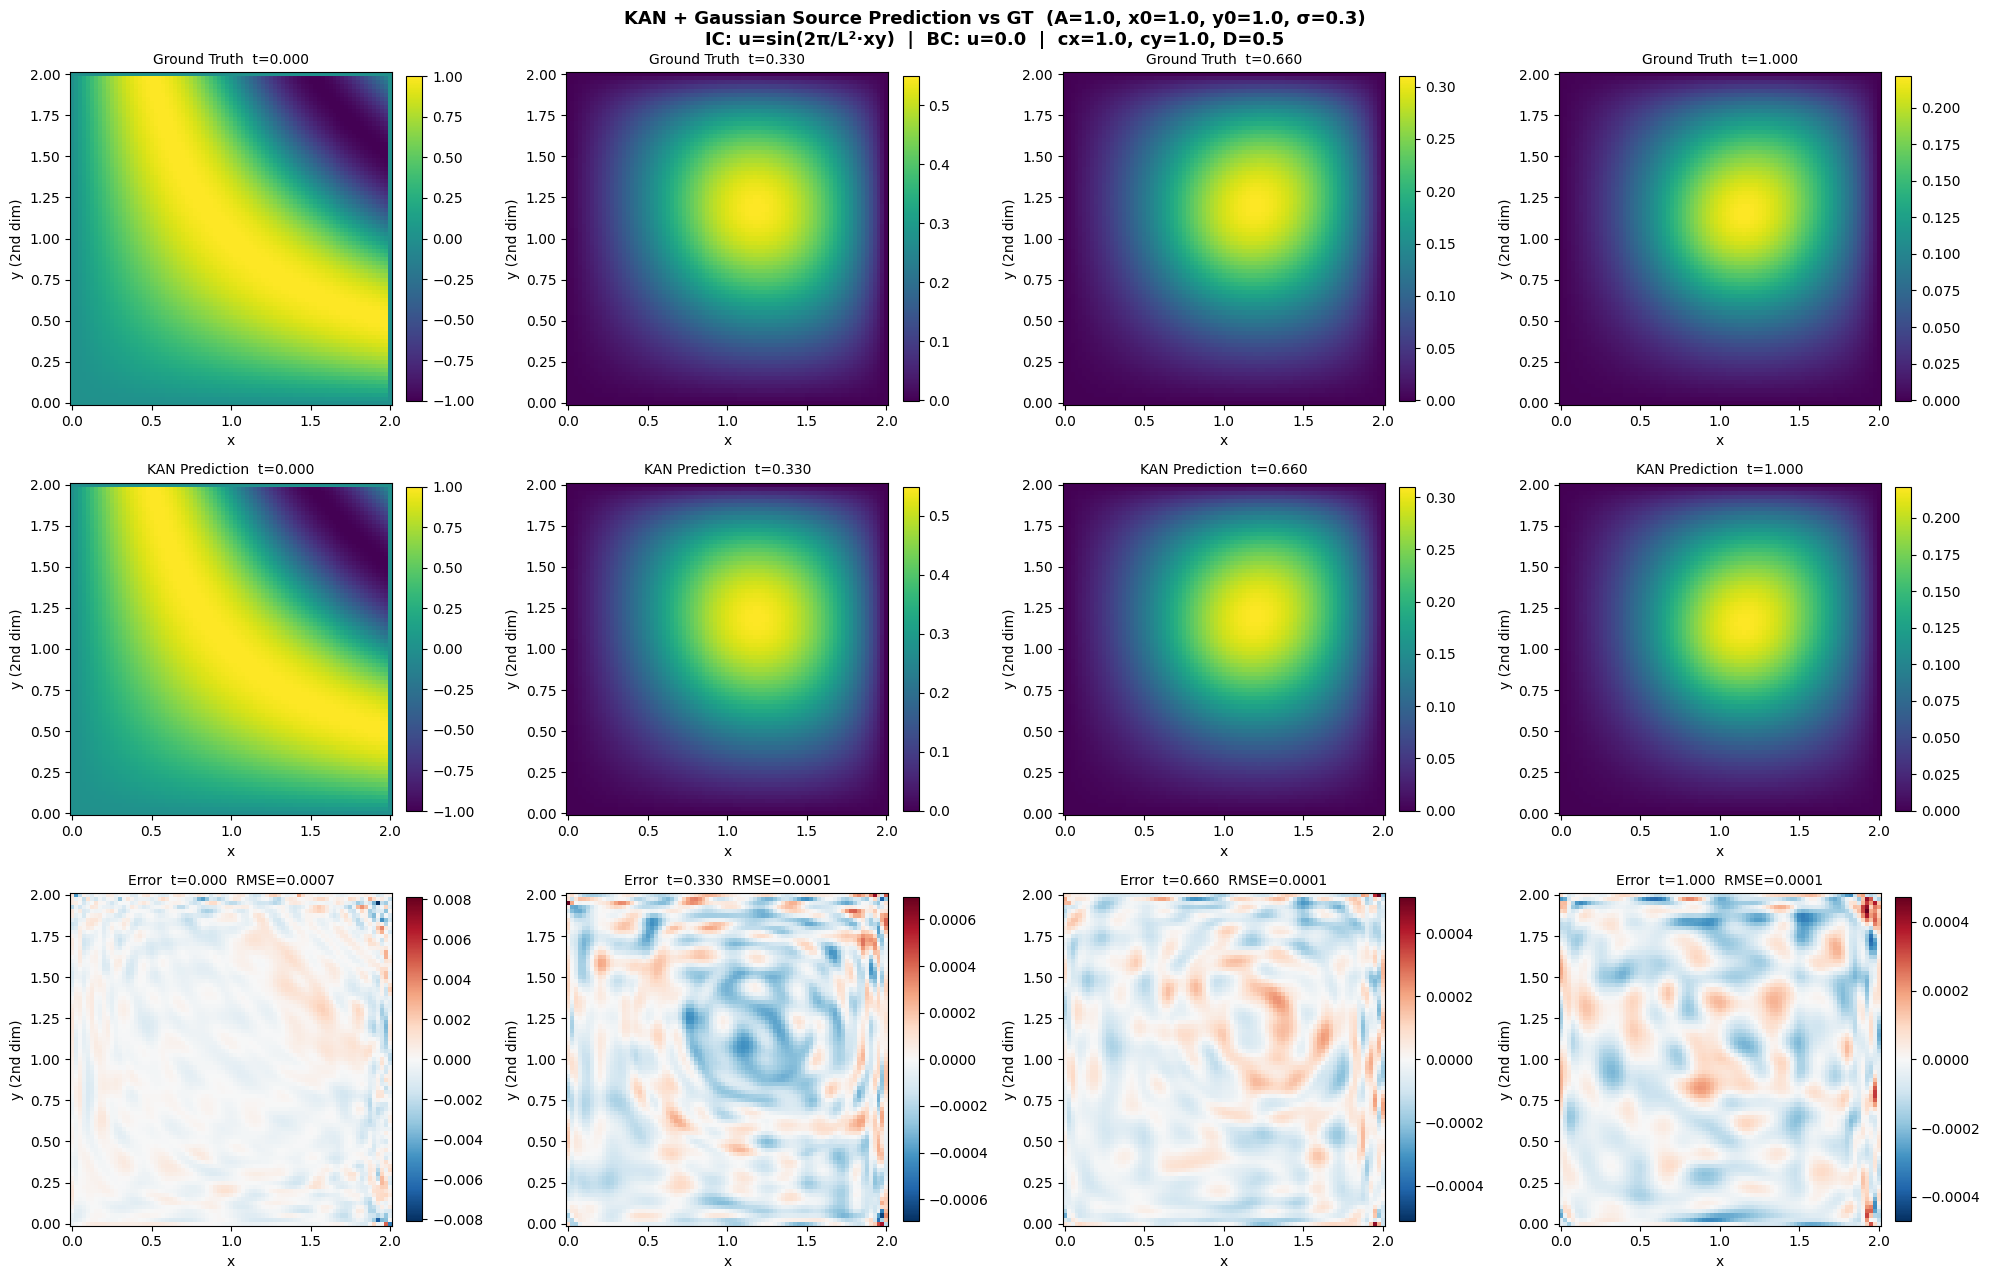

  -> saved KANGS_02_snapshot_comparison.png


In [ ]:
plot_snapshot_comparison(
    kan_gs_eval,
    f'KAN + Gaussian Source Prediction vs GT  (A={GAUSS_A}, x0={GAUSS_X0}, y0={GAUSS_Y0}, σ={GAUSS_SIGMA})\n'
    f'IC: u=sin(2π/L²·xy)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}',
    'KANGS_02_snapshot_comparison.png')

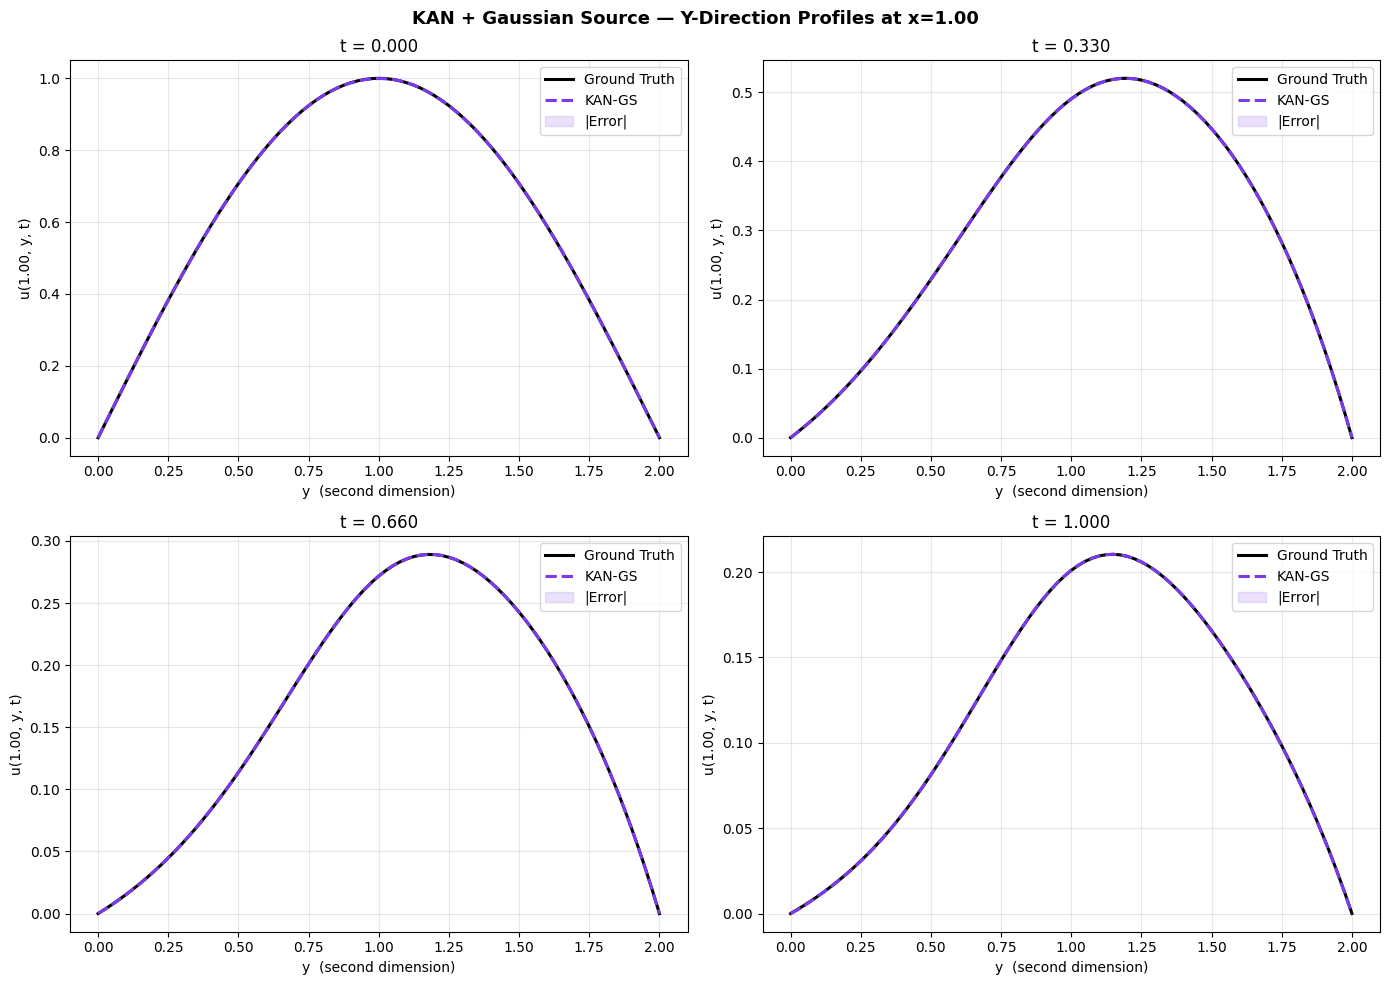

  -> saved KANGS_03_y_profiles.png


In [ ]:
plot_y_profiles(
    kan_gs_eval,
    f'KAN + Gaussian Source — Y-Direction Profiles at x={x_grid[ix_mid]:.2f}',
    'KANGS_03_y_profiles.png',
    color='#7C3AED', label=f'KAN-GS')

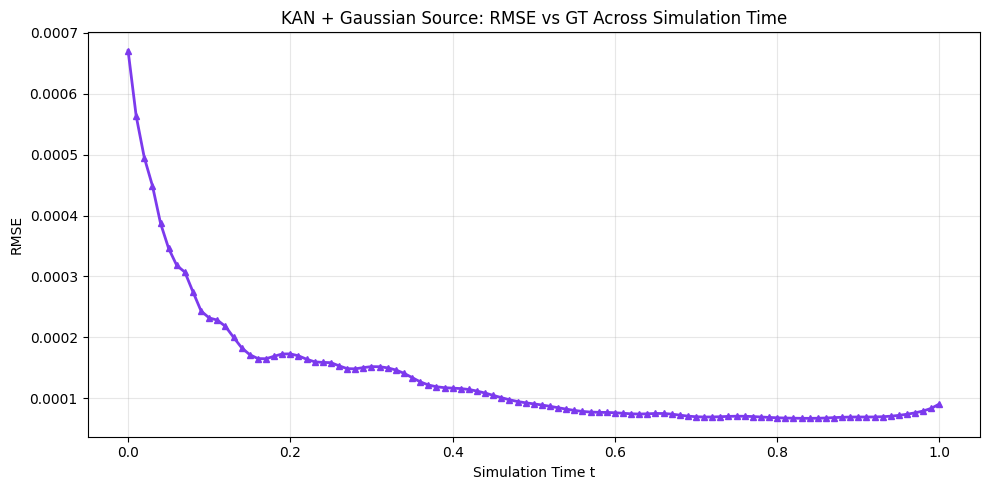

  -> saved KANGS_04_rmse_over_time.png


In [ ]:
plot_rmse_over_time(
    kan_gs_eval, '#7C3AED', '^',
    f'KAN + Gaussian Source: RMSE vs GT Across Simulation Time',
    'KANGS_04_rmse_over_time.png')

kan_gs_model.cpu()
torch.cuda.empty_cache()

## 16. KAN + Unknown Source — Model Definition

In [ ]:
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid, indexing='xy')
S_unknown = (
    UK_A1 * np.exp(-((X_mesh-UK_X1)**2 + (Y_mesh-UK_Y1)**2) / (2*UK_S1**2)) +
    UK_A2 * np.exp(-((X_mesh-UK_X2)**2 + (Y_mesh-UK_Y2)**2) / (2*UK_S2**2))
)

print('Solving Unknown-Source GT ...', flush=True)
t0 = time.time()
_, C_gt_us = solve_adi(source=S_unknown)
print(f'  Done in {time.time()-t0:.2f}s')
print(f'  u range at t=T: [{C_gt_us[-1].min():.4f}, {C_gt_us[-1].max():.4f}]')

kan_us_model    = KAN(KAN_WIDTHS, KAN_GRID_SIZE, KAN_SPLINE_ORD).to(device)
kan_us_n_params = sum(p.numel() for p in kan_us_model.parameters())
print(f'KAN-US : {KAN_WIDTHS}  grid={KAN_GRID_SIZE}  order={KAN_SPLINE_ORD}  params={kan_us_n_params:,}')

Solving Unknown-Source GT ...
  Done in 10.12s
  u range at t=T: [0.0000, 0.1107]
KAN-US : [3, 32, 32, 32, 1]  grid=8  order=3  params=26,304


## 17. Unknown Training

In [ ]:
targets_kan_us = build_targets(C_gt_us)
train_loader_us, val_loader_us, n_tr_us, n_va_us = make_data_loaders(targets_kan_us)

kan_us_result = train_kan_model(
    kan_us_model, train_loader_us, val_loader_us, n_tr_us, n_va_us, 'kan_us')


 Epoch |   Train Loss |      Val MSE |        LR |    Wall
------------------------------------------------------------
     1 |     0.007713 |     0.000617 |  3.00e-03 |   0.0s
    50 |     0.000006 |     0.000013 |  3.00e-03 | 732.5s
  [ckpt] saved  -> kan_us.pt
   100 |     0.000002 |     0.000000 |  1.50e-03 | 1450.9s
  [ckpt] saved  -> kan_us.pt
   150 |     0.000000 |     0.000000 |  7.50e-04 | 2150.1s
  [ckpt] saved  -> kan_us.pt
   200 |     0.000000 |     0.000000 |  9.38e-05 | 2838.0s
  [ckpt] saved  -> kan_us.pt

  Converged at epoch 203! |ΔLoss|=4.45e-10 < 1e-06

  Stop reason   : convergence
  Epochs run    : 203
  Best val MSE  : 0.000000
  Training time : 2892.3s (48.2 min)
  [ckpt] saved  -> kan_us_done.pt


## 18. Unknown Predictions & Metrics

In [ ]:
print('KAN + Unknown Source — Accuracy vs Ground Truth:')
kan_us_eval = evaluate_kan_model(kan_us_model, targets_kan_us)

KAN + Unknown Source — Accuracy vs Ground Truth:
  Full MSE      : 0.000000
  RMSE          : 0.000129
  Rel. L1 error : 0.05%


## 19. Unknown Plots

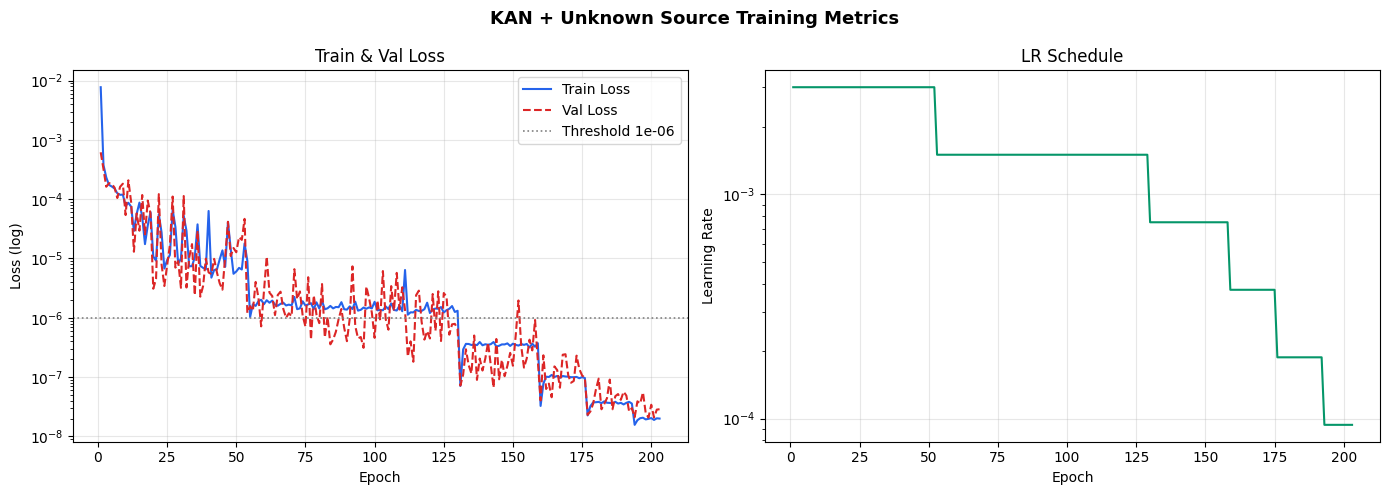

  -> saved KANUS_01_training_metrics.png


In [ ]:
plot_training_metrics(
    kan_us_result,
    'KAN + Unknown Source Training Metrics',
    'KANUS_01_training_metrics.png')

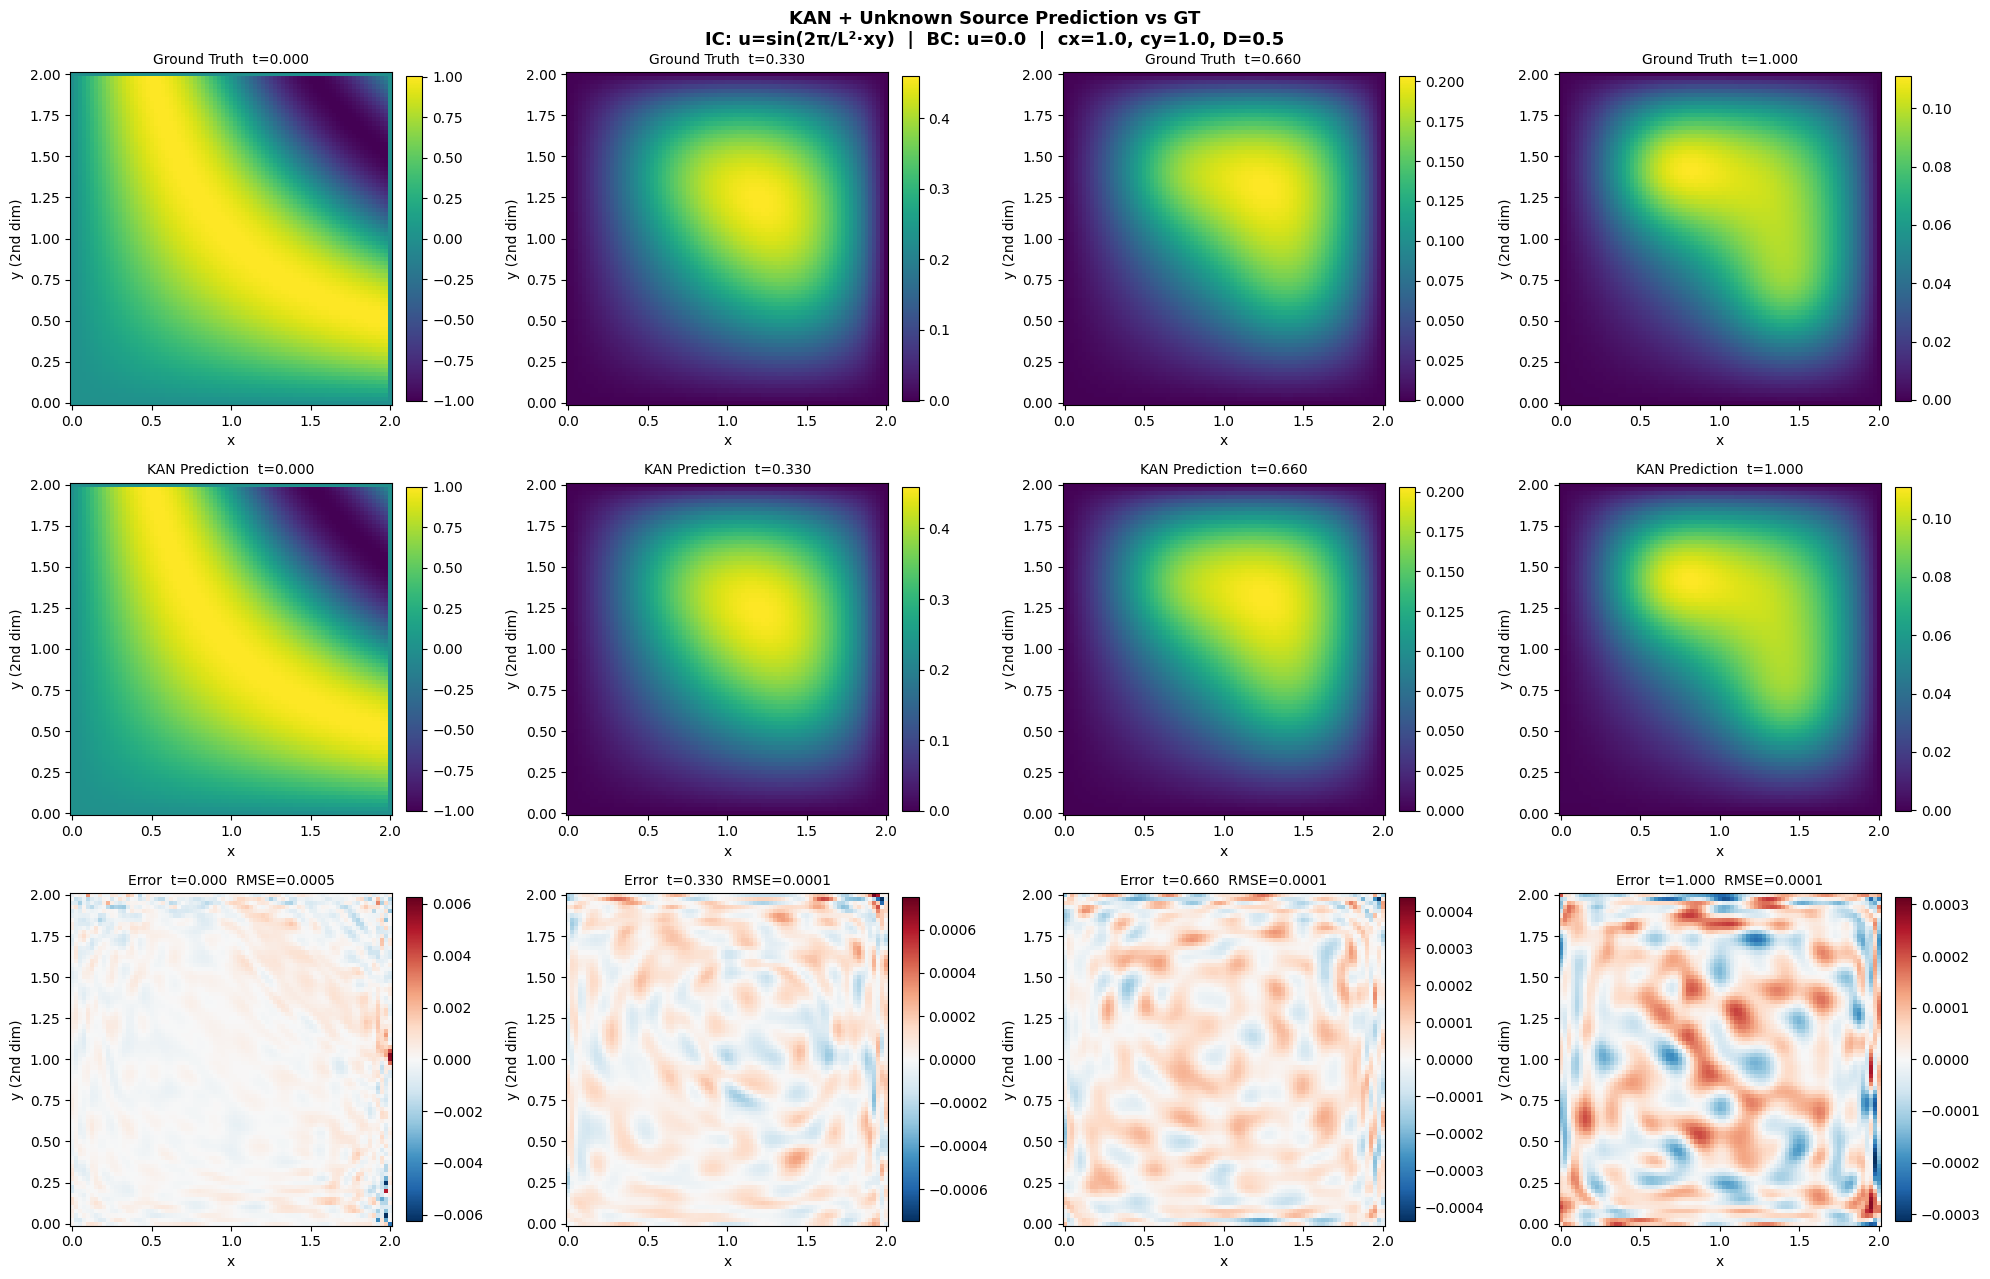

  -> saved KANUS_02_snapshot_comparison.png


In [ ]:
plot_snapshot_comparison(
    kan_us_eval,
    f'KAN + Unknown Source Prediction vs GT\n'
    f'IC: u=sin(2π/L²·xy)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}',
    'KANUS_02_snapshot_comparison.png')

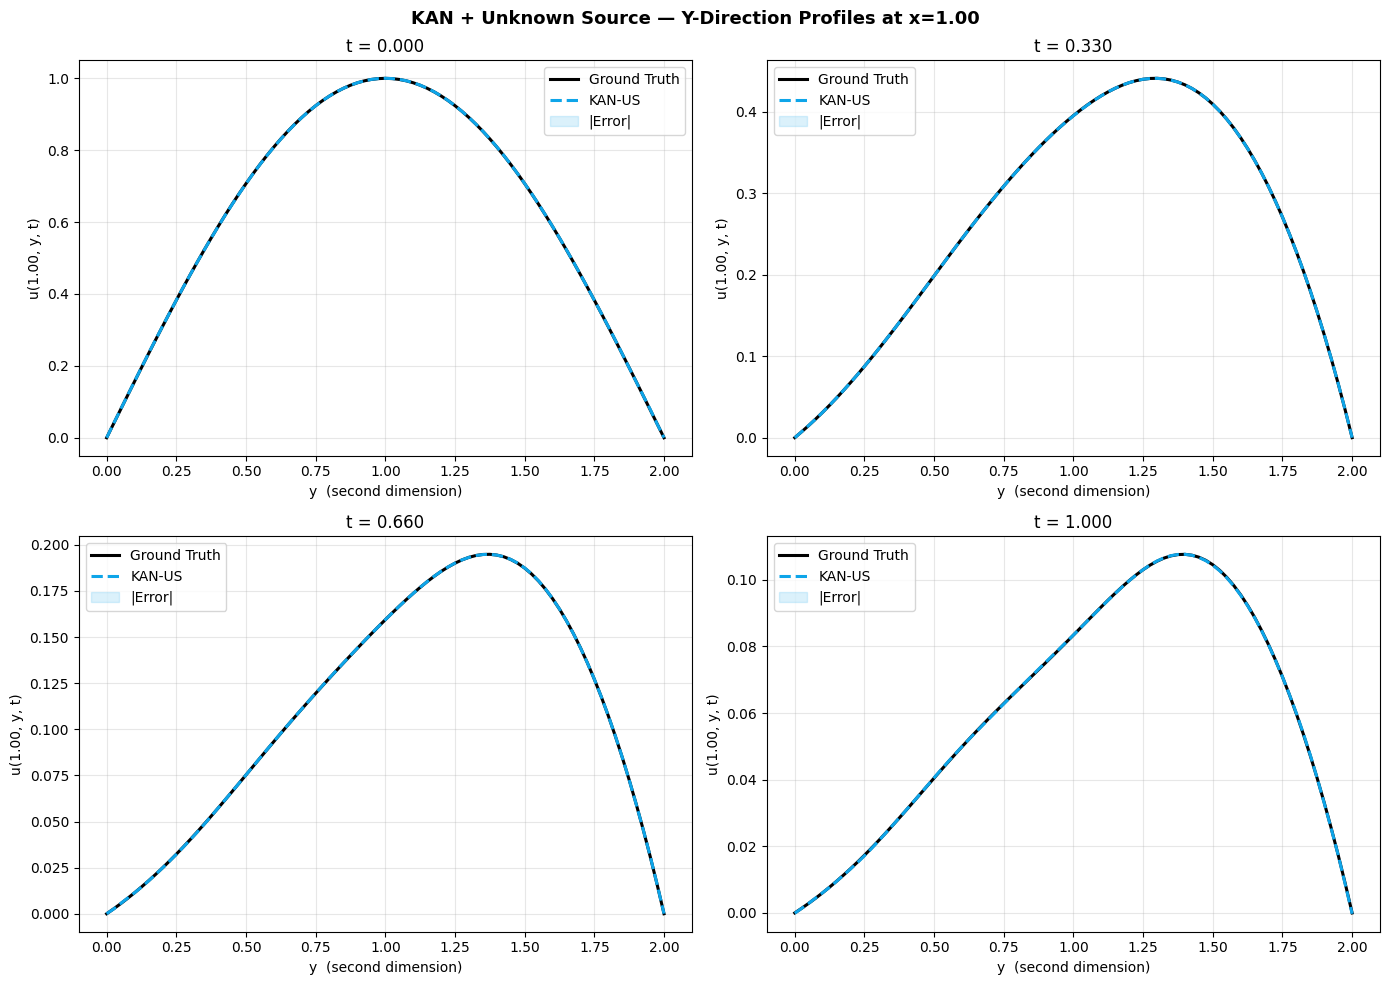

  -> saved KANUS_03_y_profiles.png


In [ ]:
plot_y_profiles(
    kan_us_eval,
    f'KAN + Unknown Source — Y-Direction Profiles at x={x_grid[ix_mid]:.2f}',
    'KANUS_03_y_profiles.png',
    color='#0EA5E9', label='KAN-US')

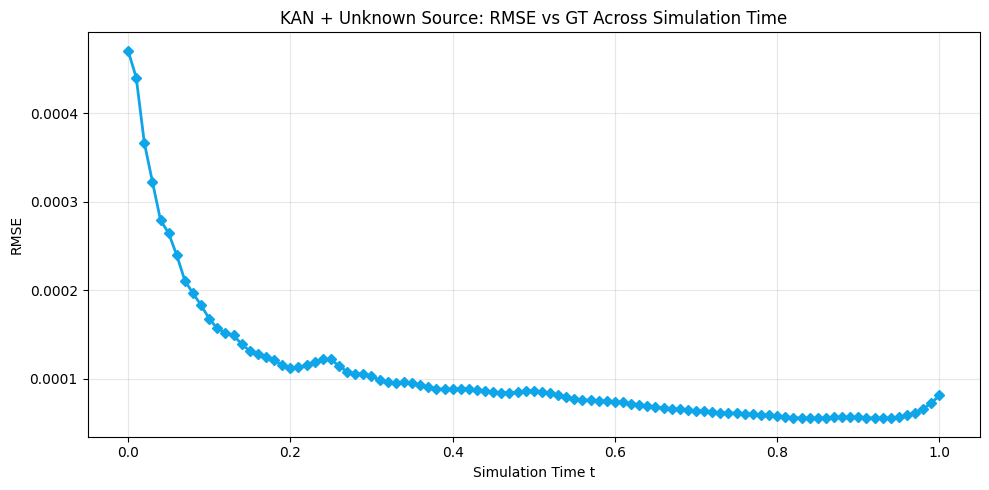

  -> saved KANUS_04_rmse_over_time.png


In [ ]:
plot_rmse_over_time(
    kan_us_eval, '#0EA5E9', 'D',
    'KAN + Unknown Source: RMSE vs GT Across Simulation Time',
    'KANUS_04_rmse_over_time.png')

kan_us_model.cpu()
torch.cuda.empty_cache()

## 20. KAN vs Constant vs Gaussian vs Unknown — Comparative Analysis

In [ ]:
kan_model.to(device)
kan_cs_model.to(device)
kan_gs_model.to(device)
kan_us_model.to(device)

for name, res in [('kan_done', kan_result), ('kan_cs_done', kan_cs_result),
                   ('kan_gs_done', kan_gs_result), ('kan_us_done', kan_us_result)]:
    _c = load_ckpt(name)
    if _c:
        for k in ('train_losses','val_losses','lr_history','final_epoch','best_val'):
            res[k] = _c[k]

compare_snaps  = [len(snap_t)//2, len(snap_t)-1]
compare_labels = ['t = T/2', 't = T']
print('Models and histories restored for comparison.')

  [ckpt] loaded <- kan_done.pt
  [ckpt] loaded <- kan_cs_done.pt
  [ckpt] loaded <- kan_gs_done.pt
  [ckpt] loaded <- kan_us_done.pt
Models and histories restored for comparison.


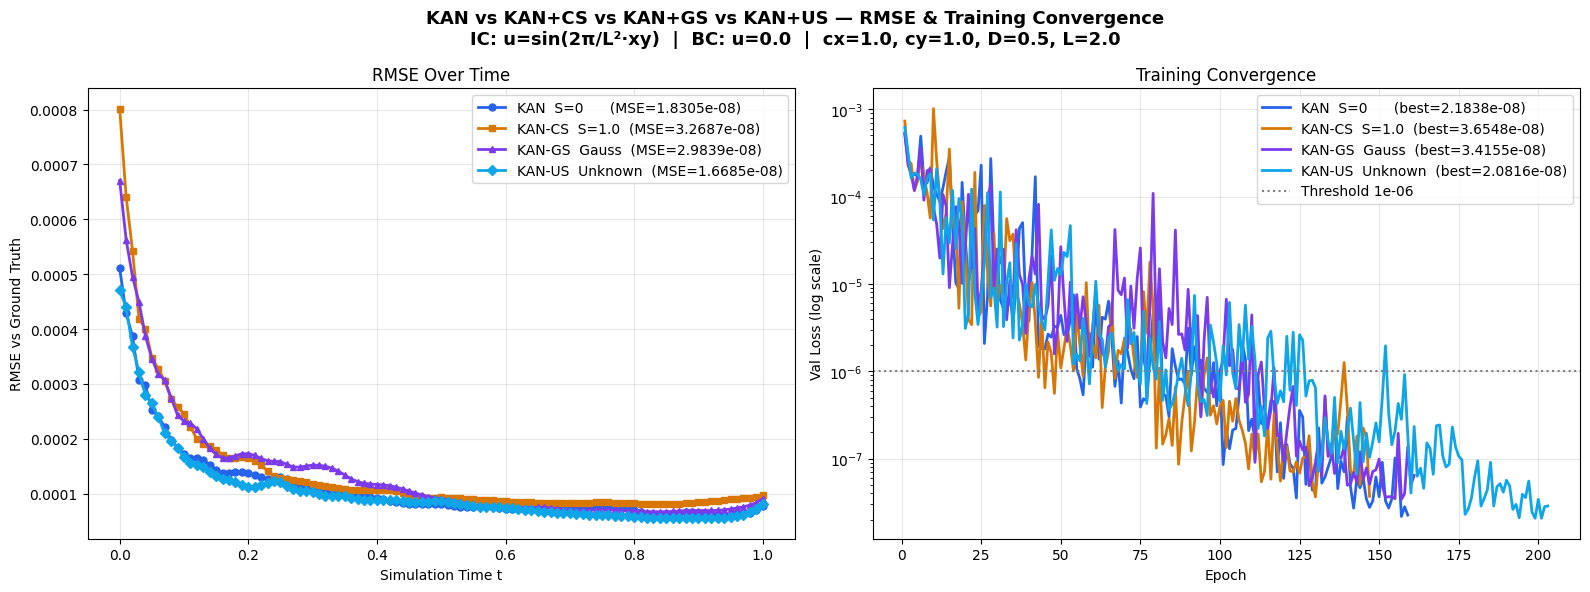

  -> saved COMPARE_01_rmse_and_convergence.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'KAN vs KAN+CS vs KAN+GS vs KAN+US — RMSE & Training Convergence\n'
    f'IC: u=sin(2π/L²·xy)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}, L={L}',
    fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(snap_t, kan_eval['rmse_t'],    'o-', color='#2563EB', lw=2, ms=5,
        label=f'KAN  S=0      (MSE={kan_eval["mse_full"]:.4e})')
ax.plot(snap_t, kan_cs_eval['rmse_t'], 's-', color='#D97706', lw=2, ms=5,
        label=f'KAN-CS  S={SOURCE_STRENGTH}  (MSE={kan_cs_eval["mse_full"]:.4e})')
ax.plot(snap_t, kan_gs_eval['rmse_t'], '^-', color='#7C3AED', lw=2, ms=5,
        label=f'KAN-GS  Gauss  (MSE={kan_gs_eval["mse_full"]:.4e})')
ax.plot(snap_t, kan_us_eval['rmse_t'], 'D-', color='#0EA5E9', lw=2, ms=5,
        label=f'KAN-US  Unknown  (MSE={kan_us_eval["mse_full"]:.4e})')
ax.set_xlabel('Simulation Time t'); ax.set_ylabel('RMSE vs Ground Truth')
ax.set_title('RMSE Over Time'); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(np.arange(1, kan_result['final_epoch']+1),    kan_result['val_losses'],
            lw=2, color='#2563EB', label=f'KAN  S=0      (best={kan_result["best_val"]:.4e})')
ax.semilogy(np.arange(1, kan_cs_result['final_epoch']+1), kan_cs_result['val_losses'],
            lw=2, color='#D97706', label=f'KAN-CS  S={SOURCE_STRENGTH}  (best={kan_cs_result["best_val"]:.4e})')
ax.semilogy(np.arange(1, kan_gs_result['final_epoch']+1), kan_gs_result['val_losses'],
            lw=2, color='#7C3AED', label=f'KAN-GS  Gauss  (best={kan_gs_result["best_val"]:.4e})')
ax.semilogy(np.arange(1, kan_us_result['final_epoch']+1), kan_us_result['val_losses'],
            lw=2, color='#0EA5E9', label=f'KAN-US  Unknown  (best={kan_us_result["best_val"]:.4e})')
ax.axhline(KAN_THRESHOLD, color='gray', ls=':', lw=1.5, label=f'Threshold {KAN_THRESHOLD:.0e}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Loss (log scale)')
ax.set_title('Training Convergence'); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('COMPARE_01_rmse_and_convergence.png')

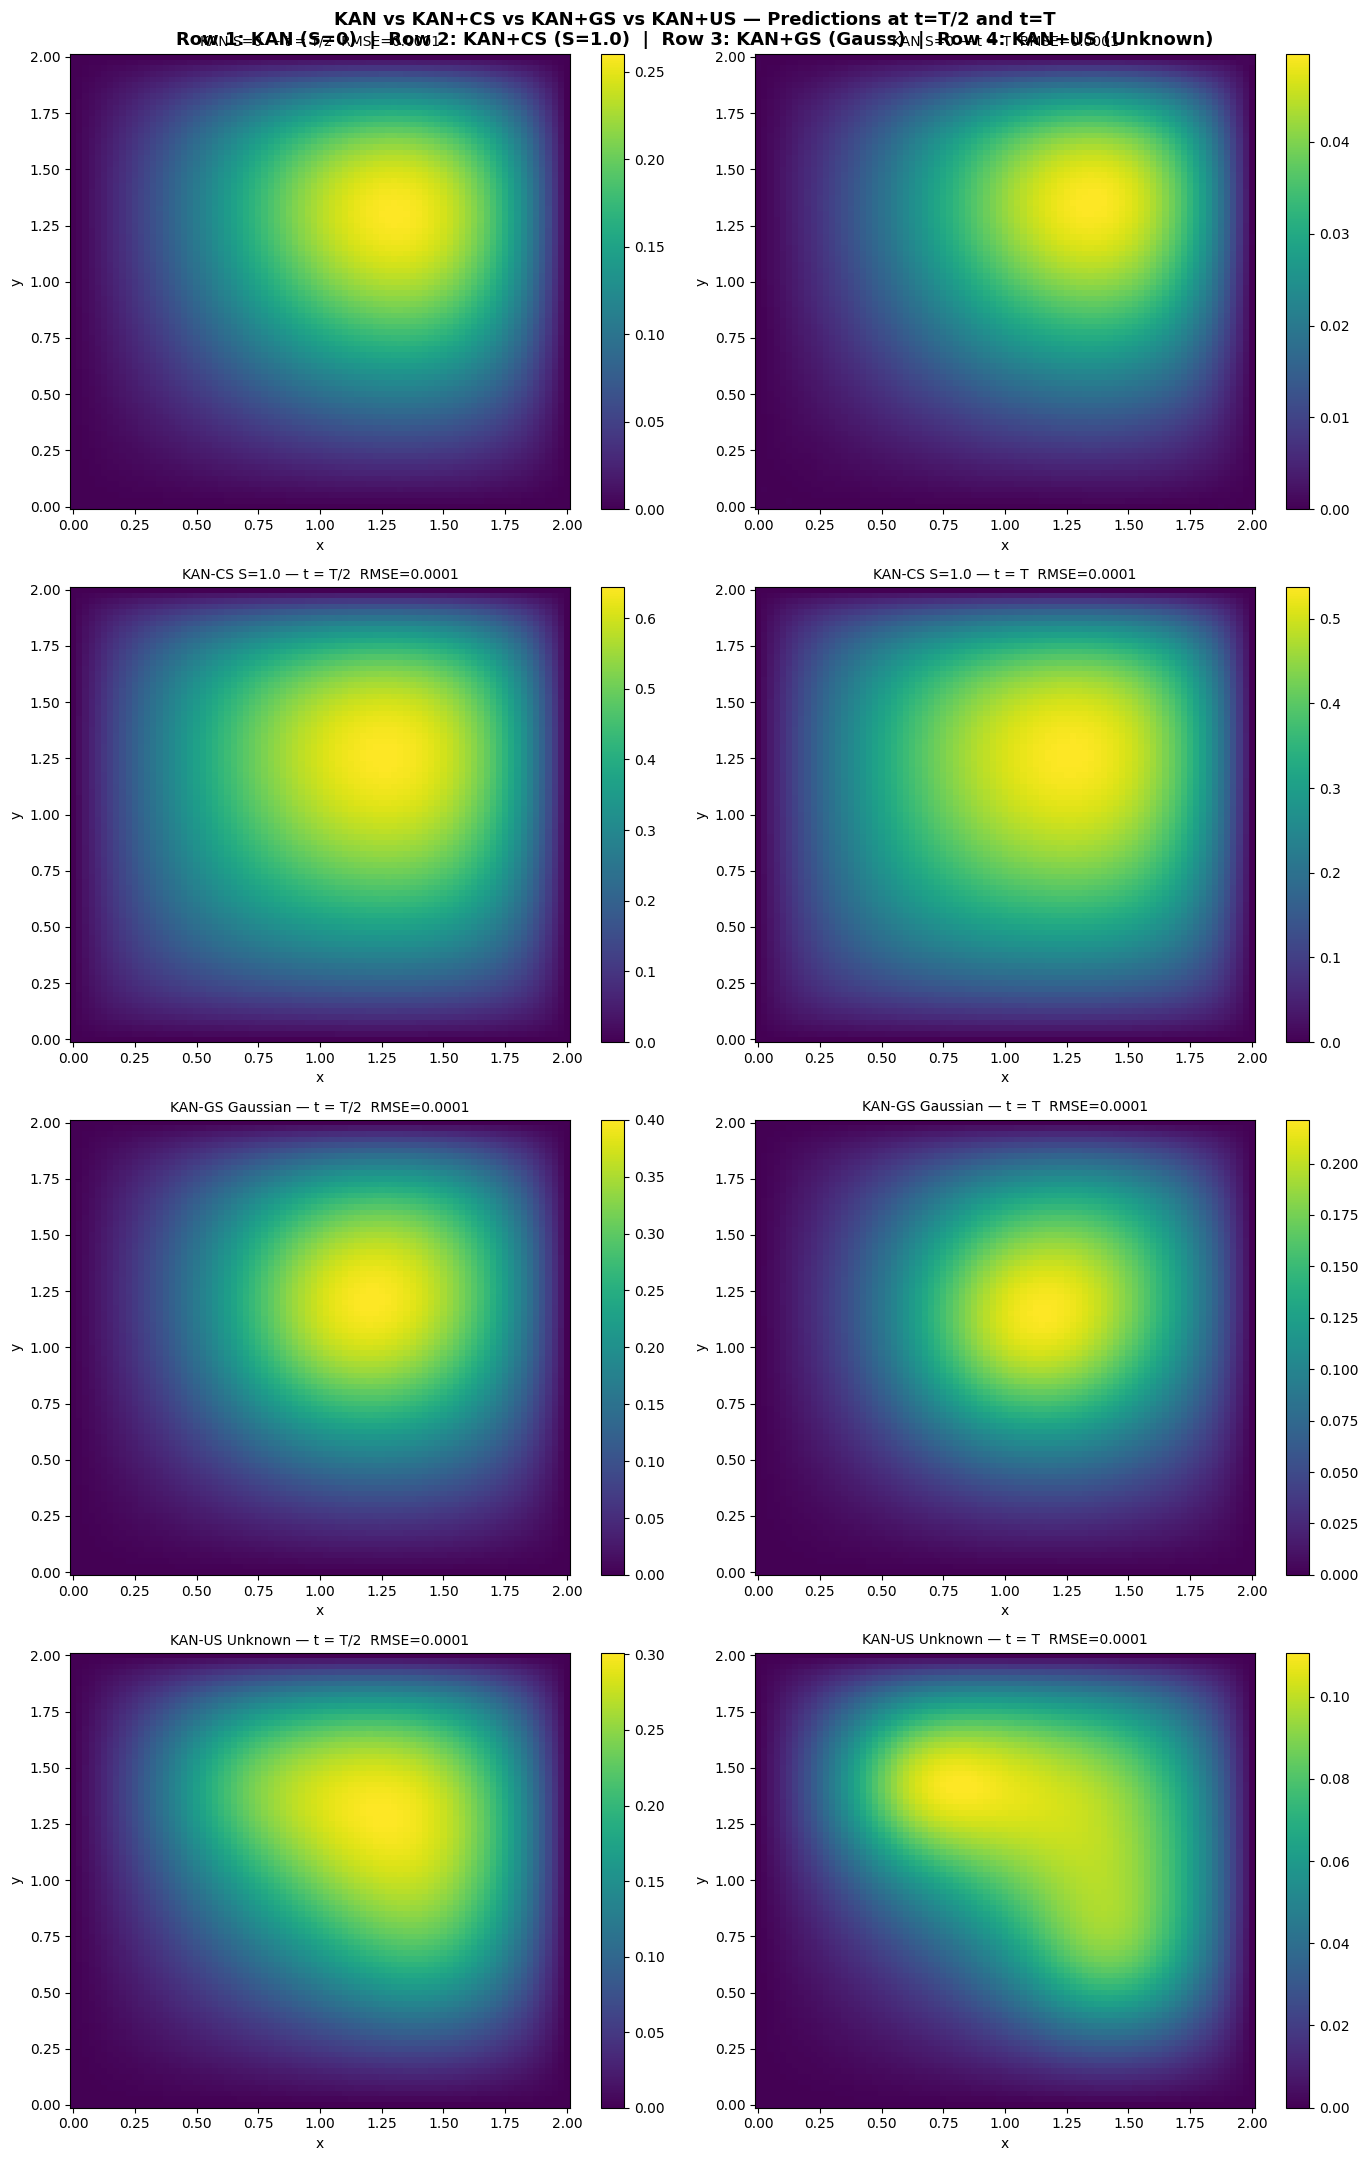

  -> saved COMPARE_02_side_by_side_predictions.png


In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 22))
fig.suptitle(
    f'KAN vs KAN+CS vs KAN+GS vs KAN+US — Predictions at t=T/2 and t=T\n'
    f'Row 1: KAN (S=0)  |  Row 2: KAN+CS (S={SOURCE_STRENGTH})  |  Row 3: KAN+GS (Gauss)  |  Row 4: KAN+US (Unknown)',
    fontsize=13, fontweight='bold')

configs = [
    (kan_eval,    '#2563EB', 'KAN S=0'),
    (kan_cs_eval, '#D97706', f'KAN-CS S={SOURCE_STRENGTH}'),
    (kan_gs_eval, '#7C3AED', 'KAN-GS Gaussian'),
    (kan_us_eval, '#0EA5E9', 'KAN-US Unknown'),
]

for row, (ev, col, lbl) in enumerate(configs):
    for c, (si, snap_lbl) in enumerate(zip(compare_snaps, compare_labels)):
        tk   = snap_t[si]
        Ugt  = ev['true_snaps'][si]
        Upd  = ev['pred_snaps'][si]
        rmse = np.sqrt(np.mean((Upd-Ugt)**2))
        vmin, vmax = Ugt.min(), Ugt.max()
        ax = axes[row, c]
        im = ax.pcolormesh(x_grid, y_grid, Upd.T, cmap='viridis', vmin=vmin, vmax=vmax)
        ax.set_title(f'{lbl} — {snap_lbl}  RMSE={rmse:.4f}', fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

plt.tight_layout()
save_and_show('COMPARE_02_side_by_side_predictions.png')

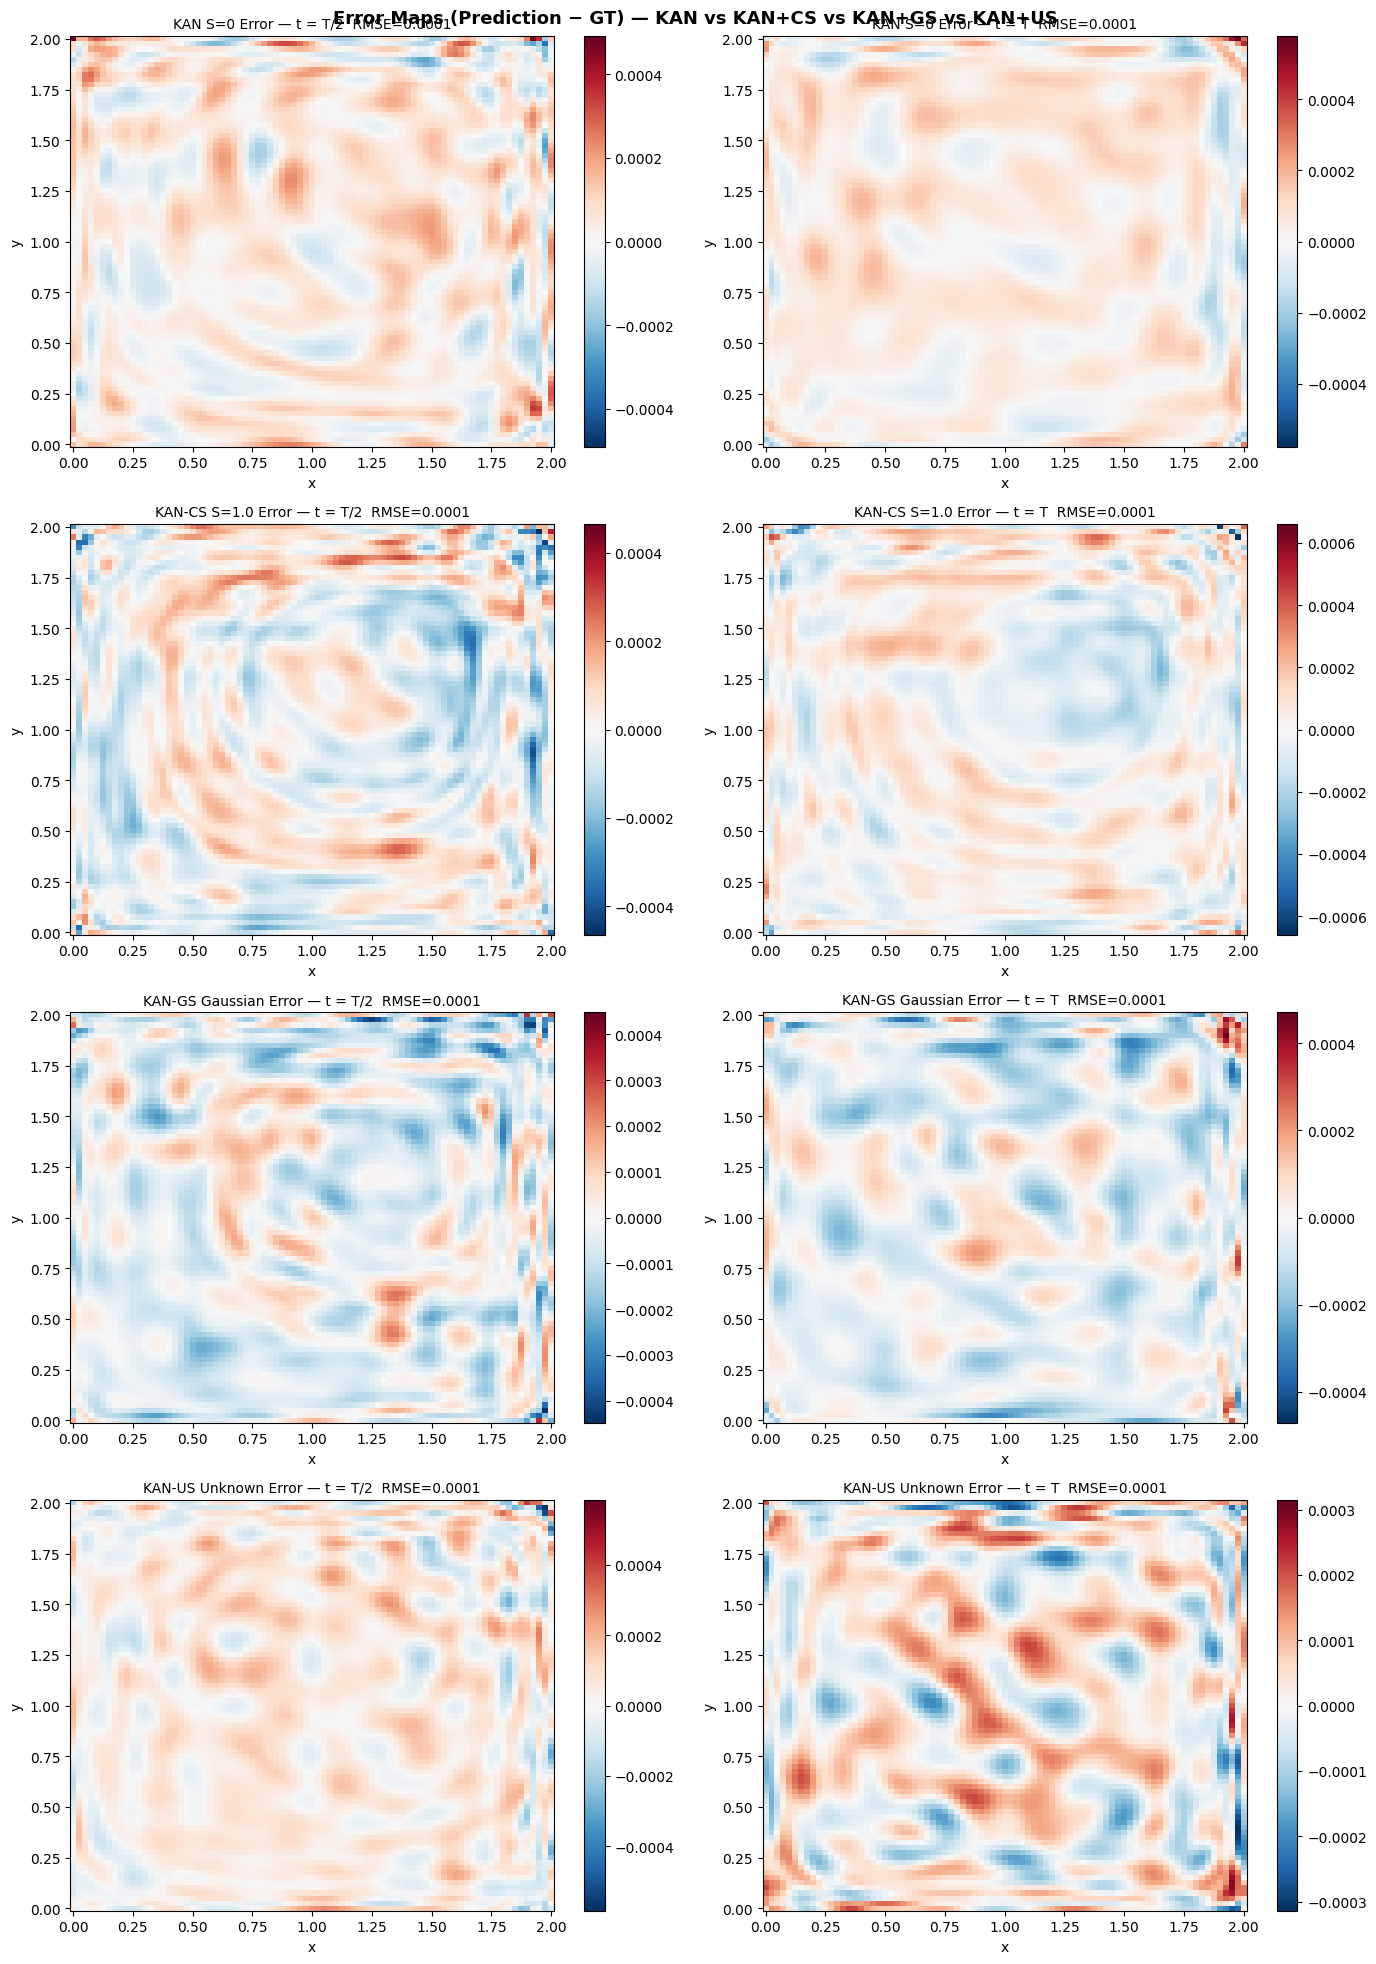

  -> saved COMPARE_03_error_maps.png


In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle(
    f'Error Maps (Prediction − GT) — KAN vs KAN+CS vs KAN+GS vs KAN+US',
    fontsize=13, fontweight='bold')

configs = [
    (kan_eval,    'KAN S=0'),
    (kan_cs_eval, f'KAN-CS S={SOURCE_STRENGTH}'),
    (kan_gs_eval, 'KAN-GS Gaussian'),
    (kan_us_eval, 'KAN-US Unknown'),
]

for row, (ev, lbl) in enumerate(configs):
    for c, (si, snap_lbl) in enumerate(zip(compare_snaps, compare_labels)):
        err  = ev['pred_snaps'][si] - ev['true_snaps'][si]
        emax = abs(err).max() + 1e-12
        norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)
        ax = axes[row, c]
        im = ax.pcolormesh(x_grid, y_grid, err.T, cmap='RdBu_r', norm=norm_e)
        ax.set_title(f'{lbl} Error — {snap_lbl}  RMSE={np.sqrt(np.mean(err**2)):.4f}', fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

plt.tight_layout()
save_and_show('COMPARE_03_error_maps.png')

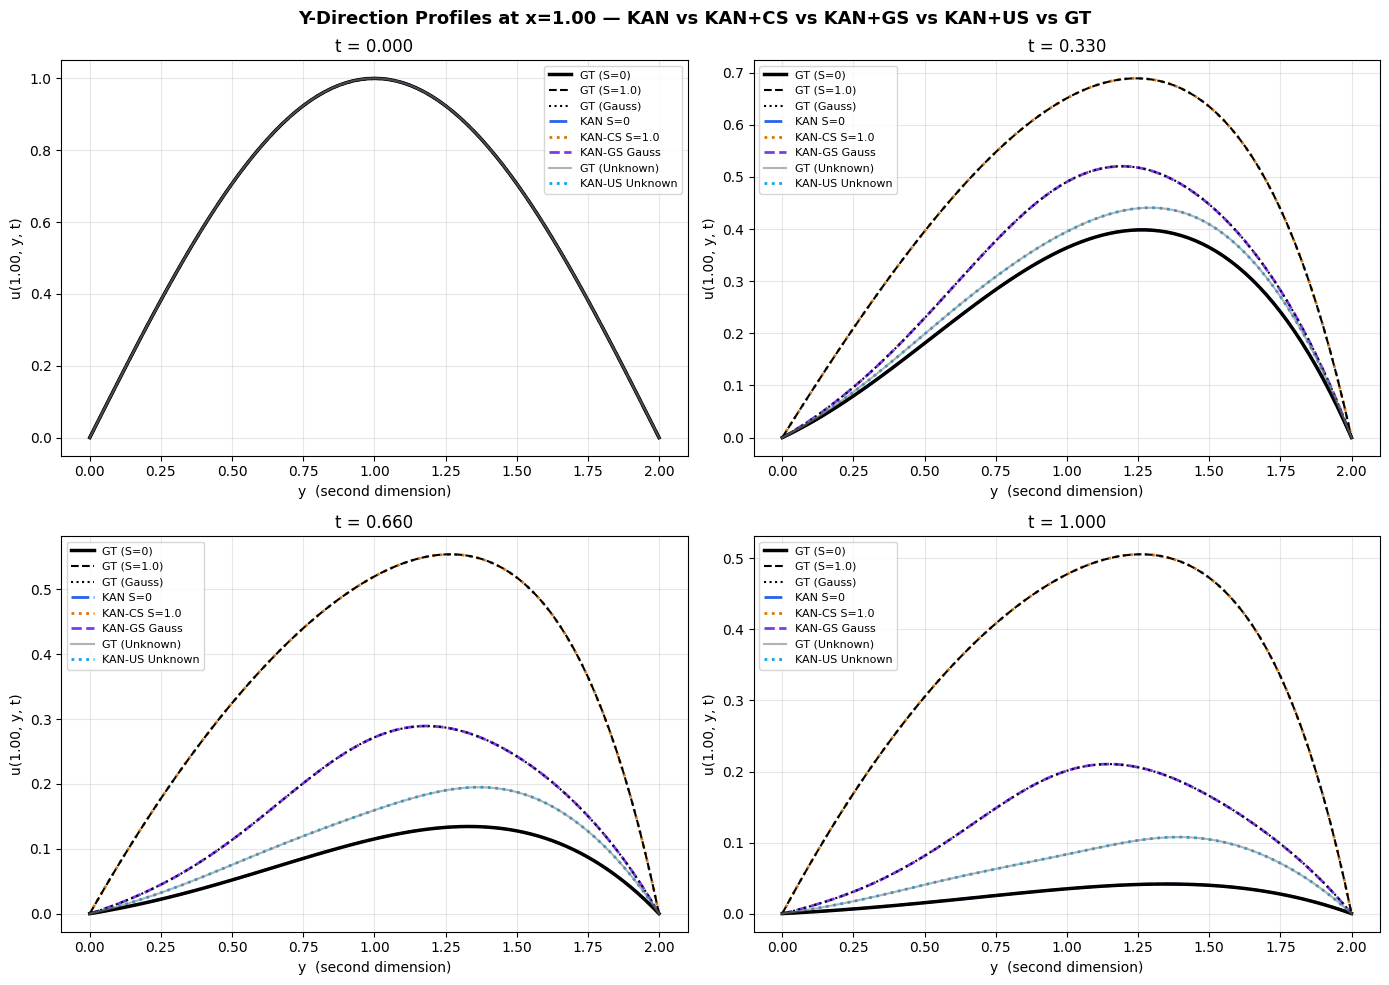

  -> saved COMPARE_04_y_profiles.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Y-Direction Profiles at x={x_grid[ix_mid]:.2f} — KAN vs KAN+CS vs KAN+GS vs KAN+US vs GT',
    fontsize=13, fontweight='bold')

for ax, si in zip(axes.ravel(), snap_idxs_4):
    tk = snap_t[si]
    ax.plot(y_grid, kan_eval['true_snaps'][si,    ix_mid, :], 'k-',  lw=2.5, label='GT (S=0)',   zorder=5)
    ax.plot(y_grid, kan_cs_eval['true_snaps'][si, ix_mid, :], 'k--', lw=1.5, label=f'GT (S={SOURCE_STRENGTH})', zorder=5)
    ax.plot(y_grid, kan_gs_eval['true_snaps'][si, ix_mid, :], 'k:',  lw=1.5, label='GT (Gauss)', zorder=5)
    ax.plot(y_grid, kan_eval['pred_snaps'][si,    ix_mid, :], color='#2563EB', ls='-.', lw=2.0, label='KAN S=0')
    ax.plot(y_grid, kan_cs_eval['pred_snaps'][si, ix_mid, :], color='#D97706', ls=':',  lw=2.0, label=f'KAN-CS S={SOURCE_STRENGTH}')
    ax.plot(y_grid, kan_gs_eval['pred_snaps'][si, ix_mid, :], color='#7C3AED', ls='--', lw=2.0, label='KAN-GS Gauss')
    ax.plot(y_grid, kan_us_eval['true_snaps'][si, ix_mid, :], color='gray',    ls='-',  lw=1.5, label='GT (Unknown)', alpha=0.6, zorder=5)
    ax.plot(y_grid, kan_us_eval['pred_snaps'][si, ix_mid, :], color='#0EA5E9', ls=':',  lw=2.0, label='KAN-US Unknown')
    ax.set_title(f't = {tk:.3f}', fontsize=12)
    ax.set_xlabel('y  (second dimension)'); ax.set_ylabel(f'u({x_grid[ix_mid]:.2f}, y, t)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('COMPARE_04_y_profiles.png')

## 21. Final Summary

In [ ]:
print('\n' + '='*75)
print('  FINAL SUMMARY — KAN: No Source vs Constant vs Gaussian vs Unknown Source')
print('='*75)
print(f'  PDE    : du/dt + {CX}·du/dx + {CY}·du/dy = {D}·(d²u/dx² + d²u/dy²) + S')
print(f'  IC     : u(x,y,0) = sin(2π/L²·xy)')
print(f'  BC     : u = {BC_VAL}  (Dirichlet, all boundaries)')
print(f'  Domain : x,y ∈ [0,{L}]  t ∈ [0,{T}]')
print(f'  Grid   : Nx=Ny={Nx}  Dx=Dy={DX:.4f}  Dt={DT}')
print(f'  GT     : ADI Crank-Nicolson')
print()

C1 = 'KAN  S=0'
C2 = f'KAN-CS  S={SOURCE_STRENGTH}'
C3 = 'KAN-GS  Gauss'
C4 = 'KAN-US  Unknown'
print(f'  {"":26s} {C1:>14} {C2:>14} {C3:>14} {C4:>14}')
print(f'  {"-"*82}')
print(f'  {"Stop reason":<26} {kan_result["stop_reason"]:>14} {kan_cs_result["stop_reason"]:>14} {kan_gs_result["stop_reason"]:>14} {kan_us_result["stop_reason"]:>14}')
print(f'  {"Epochs run":<26} {kan_result["final_epoch"]:>14} {kan_cs_result["final_epoch"]:>14} {kan_gs_result["final_epoch"]:>14} {kan_us_result["final_epoch"]:>14}')
print(f'  {"Best val MSE":<26} {kan_result["best_val"]:>14.6f} {kan_cs_result["best_val"]:>14.6f} {kan_gs_result["best_val"]:>14.6f} {kan_us_result["best_val"]:>14.6f}')
print(f'  {"Full-dataset MSE":<26} {kan_eval["mse_full"]:>14.6f} {kan_cs_eval["mse_full"]:>14.6f} {kan_gs_eval["mse_full"]:>14.6f} {kan_us_eval["mse_full"]:>14.6f}')
print(f'  {"RMSE":<26} {kan_eval["rmse_all"]:>14.6f} {kan_cs_eval["rmse_all"]:>14.6f} {kan_gs_eval["rmse_all"]:>14.6f} {kan_us_eval["rmse_all"]:>14.6f}')
print(f'  {"Rel. L1 error":<26} {kan_eval["rel_err"]*100:>13.2f}% {kan_cs_eval["rel_err"]*100:>13.2f}% {kan_gs_eval["rel_err"]*100:>13.2f}% {kan_us_eval["rel_err"]*100:>13.2f}%')
print(f'  {"Training time":<26} {kan_result["total_time"]/60:>11.1f} min {kan_cs_result["total_time"]/60:>11.1f} min {kan_gs_result["total_time"]/60:>11.1f} min {kan_us_result["total_time"]/60:>11.1f} min')
print()
print(f'  All plots saved to: {OUT_DIR}/')
print('='*75)


  FINAL SUMMARY — KAN: No Source vs Constant vs Gaussian vs Unknown Source
  PDE    : du/dt + 1.0·du/dx + 1.0·du/dy = 0.5·(d²u/dx² + d²u/dy²) + S
  IC     : u(x,y,0) = sin(2π/L²·xy)
  BC     : u = 0.0  (Dirichlet, all boundaries)
  Domain : x,y ∈ [0,2.0]  t ∈ [0,1.0]
  Grid   : Nx=Ny=80  Dx=Dy=0.0250  Dt=0.002
  GT     : ADI Crank-Nicolson

                                   KAN  S=0  KAN-CS  S=1.0  KAN-GS  Gauss KAN-US  Unknown
  ----------------------------------------------------------------------------------
  Stop reason                   convergence    convergence    convergence    convergence
  Epochs run                            159            147            161            203
  Best val MSE                     0.000000       0.000000       0.000000       0.000000
  Full-dataset MSE                 0.000000       0.000000       0.000000       0.000000
  RMSE                             0.000135       0.000181       0.000173       0.000129
  Rel. L1 error                     